## Preprocessing 

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.ticker import ScalarFormatter
from sklearn.utils import shuffle
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy import signal, stats
from scipy.signal import find_peaks
import os
import glob
from pathlib import Path
import random
import emlearn
import pickle
from datetime import datetime


In [ ]:
all_data = {}
base_names = []
processing_data = {} #For the Machine Learning and shit. 
folder_names=['DataToUpload/Data_RawIR-test', 'DataToUpload/Data_ProcessedIR-test', 'DataToUpload/Data_RealResults']
temp_skip_list = []
for folder in folder_names:
    if not os.path.exists(folder):
        print(f"Folder {folder} not found, skipping...")
        continue
        
    csv_files = glob.glob(os.path.join(folder, '*.csv'))
    
    for file in csv_files:
        base_name = os.path.basename(file).replace('-Putty-RawData.csv', '').replace('-Putty-ProcIRData.csv', '').replace('-RealData.csv', '').replace('-Putty-RealData.csv', '')
        temp_flip = 0
        if base_name not in temp_skip_list:
            if base_name not in base_names:
                base_names.append(base_name)
            
            if base_name not in all_data:
                all_data[base_name] = {}
            
            if 'RawData' in file:
                data_type = 'raw'
            elif 'RealData' in file:
                data_type = 'result'
            else:
                data_type = 'processed'
            
            df = pd.read_csv(file)
            
            if data_type == 'raw':
                all_data[base_name]['raw'] = df
            elif data_type == 'result':
                all_data[base_name]['result'] = df
            else:
                all_data[base_name]['processed'] = df

print("Done!")

Done!


In [37]:
base_names 



['2026-03-19-M1',
 '2026-03-28-F1',
 '2026-03-28-F2',
 '2026-03-28-M2',
 '2026-03-31-F3',
 '2026-03-31-M2',
 '2026-03-31-M3',
 '2026-03-31-M4',
 '2026-03-31-M5',
 '2026-04-01-M6',
 '2026-04-01-M7',
 '2026-04-01-M8',
 '2026-04-02-M9',
 '2026-04-03-M10',
 '2026-04-15-M11',
 '2026-04-21-M13',
 '2026-05-02-064619-P1-esp32-M',
 '2026-05-02-065658-P2-esp32-F',
 '2026-05-02-070515-P3-esp32-F',
 '2026-05-02-071924-P4-esp32-M',
 '2026-05-02-072832-P5-esp32-F',
 '2026-05-05-063240-C8-esp32-M',
 '2026-05-05-065954-P6-esp32-F',
 '2026-05-15-065717-C9-esp32-M',
 '2026-05-15-070853-P7-esp32-F',
 '2026-05-15-071737-P8-esp32-F']

### I Feature Extract On These Data 

In [38]:

    
    # processing_data = pd.DataFrame(["IR_raw_mean", "IR_raw_std", "IR_raw_min", "IR_raw_max", "IR_raw_q25", "IR_raw_q50", "IR_raw_q75", "IR_raw_IQR", "IR_raw_skew", "IR_raw_kurtosis", "IR_raw_rms", "IR_raw_peak2peak",  "IR_raw_skew", "IR_raw_kurtosis", "IR_raw_zcr", "IR_raw_slope", "IR_raw_mean_change", "IR_raw_change_std", "IR_raw_peaks", "IR_raw_avg_peak", "Red_raw_mean", "Red_raw_std", "Red_raw_min", "Red_raw_max", "Red_raw_q25", "Red_raw_q50", "Red_raw_q75", "Red_raw_IQR", "Red_raw_skew", "Red_raw_kurtosis", "Red_raw_rms", "Red_raw_peak2peak",  "Red_raw_skew", "Red_raw_kurtosis", "Red_raw_zcr", "Red_raw_slope", "Red_raw_mean_change", "Red_raw_change_std", "Red_raw_peaks", "Red_raw_avg_peak", "GSR_raw_mean", "GSR_raw_std", "GSR_raw_min", "GSR_raw_max", "GSR_raw_q25", "GSR_raw_q50", "GSR_raw_q75", "GSR_raw_IQR", "GSR_raw_skew", "GSR_raw_kurtosis", "GSR_raw_rms", "GSR_raw_peak2peak",  "GSR_raw_skew", "GSR_raw_kurtosis", "GSR_raw_zcr", "GSR_raw_slope", "GSR_raw_mean_change", "GSR_raw_change_std", "GSR_raw_peaks", "GSR_raw_avg_peak", "Glucose", "Uraic Acid", "Chol."])


In [39]:
processing_data = pd.DataFrame(columns=[
    "IR_raw_mean", "IR_raw_std", "IR_raw_min", "IR_raw_max", "IR_raw_q25", "IR_raw_q50", "IR_raw_q75", "IR_raw_IQR", "IR_raw_skew", "IR_raw_kurtosis", "IR_raw_rms", "IR_raw_peak2peak",  "IR_raw_slope", "IR_raw_peaks", "IR_raw_avg_peak", "Red_raw_mean", "Red_raw_std", "Red_raw_min", "Red_raw_max", "Red_raw_q25", "Red_raw_q50", "Red_raw_q75", "Red_raw_IQR", "Red_raw_skew", "Red_raw_kurtosis", "Red_raw_rms", "Red_raw_peak2peak", "Red_raw_slope",  "Red_raw_peaks", "Red_raw_avg_peak", "GSR_raw_mean", "GSR_raw_std", "GSR_raw_min", "GSR_raw_max", "GSR_raw_q25", "GSR_raw_q50", "GSR_raw_q75", "GSR_raw_IQR", "GSR_raw_skew", "GSR_raw_kurtosis", "GSR_raw_rms", "GSR_raw_peak2peak", "GSR_raw_slope",  "GSR_raw_peaks", "GSR_raw_avg_peak", "Glucose", "Uraic Acid", "Chol."
])

for name in base_names:
    temp_dict = {}
    for feature in ["IR_raw", "Red_raw", "GSR_raw"]:
        print(f"Processing {name}")
        temp_dict[f"{feature}_mean"] =  all_data[name]["raw"][f"{feature}"].mean()
        temp_dict[f"{feature}_std"] = all_data[name]["raw"][f"{feature}"].std()
        temp_dict[f"{feature}_min"] = all_data[name]["raw"][f"{feature}"].min()
        temp_dict[f"{feature}_max"] = all_data[name]["raw"][f"{feature}"].max()
        temp_dict[f"{feature}_q25"] = all_data[name]["raw"][f"{feature}"].quantile(0.25)
        temp_dict[f"{feature}_q50"] = all_data[name]["raw"][f"{feature}"].quantile(0.5)
        temp_dict[f"{feature}_q75"] = all_data[name]["raw"][f"{feature}"].quantile(0.75)
        temp_dict[f"{feature}_IQR"] = all_data[name]["raw"][f"{feature}"].quantile(0.75) - all_data[name]["raw"][f"{feature}"].quantile(0.25)
        temp_dict[f"{feature}_skew"] = stats.skew(all_data[name]["raw"][f"{feature}"])
        temp_dict[f"{feature}_kurtosis"] = stats.kurtosis(all_data[name]["raw"][f"{feature}"])
        temp_dict[f"{feature}_rms"] = np.sqrt(np.mean(all_data[name]["raw"][f"{feature}"]**2))
        temp_dict[f"{feature}_peak2peak"] = np.ptp(all_data[name]["raw"][f"{feature}"])
        temp_dict[f"{feature}_slope"] = np.polyfit((all_data[name]["raw"][f"Time_0.1s"].values * 100), all_data[name]["raw"][f"{feature}"].values, 1 )
        # temp_dx = np.gradient(all_data[name]["raw"][f"{feature}"].values, (all_data[name]["raw"][f"Time_0.1s"].values * 100))
        # temp_dict[f"{feature}_mean_change"] = np.mean(temp_dx)
        peaks, _ = signal.find_peaks(all_data[name]["raw"][f"{feature}"], height=None, distance=5)
        temp_dict[f"{feature}_peaks"] = len(peaks)
        temp_dict[f"{feature}_avg_peak"] = np.mean(peaks)
        
        
        temp_dict[f"Glucose"] = all_data[name]['result'][' glu'].item()
        temp_dict[f"Uraic Acid"] = all_data[name]['result'][' uraacid'].item()
        temp_dict[f"Chol."] = all_data[name]['result']['chol'].item()

        
        temp_df = pd.DataFrame([temp_dict])
        
    processing_data = pd.concat([processing_data, temp_df])


        
processing_data.head()

Processing 2026-03-19-M1
Processing 2026-03-19-M1
Processing 2026-03-19-M1
Processing 2026-03-28-F1
Processing 2026-03-28-F1
Processing 2026-03-28-F1
Processing 2026-03-28-F2
Processing 2026-03-28-F2
Processing 2026-03-28-F2
Processing 2026-03-28-M2
Processing 2026-03-28-M2
Processing 2026-03-28-M2
Processing 2026-03-31-F3
Processing 2026-03-31-F3
Processing 2026-03-31-F3
Processing 2026-03-31-M2
Processing 2026-03-31-M2
Processing 2026-03-31-M2
Processing 2026-03-31-M3
Processing 2026-03-31-M3
Processing 2026-03-31-M3
Processing 2026-03-31-M4
Processing 2026-03-31-M4
Processing 2026-03-31-M4
Processing 2026-03-31-M5
Processing 2026-03-31-M5
Processing 2026-03-31-M5
Processing 2026-04-01-M6
Processing 2026-04-01-M6
Processing 2026-04-01-M6
Processing 2026-04-01-M7
Processing 2026-04-01-M7
Processing 2026-04-01-M7
Processing 2026-04-01-M8
Processing 2026-04-01-M8
Processing 2026-04-01-M8
Processing 2026-04-02-M9
Processing 2026-04-02-M9
Processing 2026-04-02-M9
Processing 2026-04-03-M10

,IR_raw_mean,IR_raw_std,IR_raw_min,IR_raw_max,IR_raw_q25,IR_raw_q50,IR_raw_q75,IR_raw_IQR,IR_raw_skew,IR_raw_kurtosis,...,GSR_raw_skew,GSR_raw_kurtosis,GSR_raw_rms,GSR_raw_peak2peak,GSR_raw_slope,GSR_raw_peaks,GSR_raw_avg_peak,Glucose,Uraic Acid,Chol.
0,9213.44697,363.184948,8711,10566,8909.0,9173.0,9416.0,507.0,0.965451,0.825571,...,3.839568,51.94202,549.914145,86,"[0.00016761836334525055, 544.8124131093473]",426,1656.969484,115,3.0,195
0,9866.167418,179.365736,9483,10260,9724.5,9875.0,9999.0,274.5,-0.049546,-0.907368,...,0.332327,-0.708701,395.207631,57,"[0.00036355159290282876, 384.13582000530715]",435,1626.634483,110,5.4,206
0,11373.012432,263.840542,10794,11956,11166.0,11362.0,11570.0,404.0,0.046918,-0.824396,...,0.125298,1.348233,214.411442,92,"[-0.0003531841827002878, 224.9410485542547]",529,2015.869565,108,4.9,243
0,11113.892177,240.8622,10602,11886,10934.0,11071.5,11261.0,327.0,0.713359,0.189622,...,1.369306,8.2189,611.994998,88,"[-0.0003464462212028998, 622.447582945992]",517,1987.667311,67,9.3,192
0,8199.824221,46.114736,8058,8293,8167.0,8207.0,8234.0,67.0,-0.485104,-0.454063,...,0.095694,1.357295,406.245378,160,"[-0.0003356042210886807, 415.9817829830055]",309,1783.067961,99,6.7,297


In [40]:
## Inform of us Clark Error Grid

processing_data["Glucose"].mean()


np.float64(102.46153846153847)

In [41]:
## Inform of us Clark Error Grid

processing_data["Chol."].mean()

np.float64(182.6153846153846)

In [42]:
## Inform of us Clark Error Grid

processing_data["Uraic Acid"].mean()

np.float64(6.326923076923077)

In [43]:
processing_data.info()

<class 'pandas.DataFrame'>
Index: 26 entries, 0 to 0
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   IR_raw_mean        26 non-null     object
 1   IR_raw_std         26 non-null     object
 2   IR_raw_min         26 non-null     object
 3   IR_raw_max         26 non-null     object
 4   IR_raw_q25         26 non-null     object
 5   IR_raw_q50         26 non-null     object
 6   IR_raw_q75         26 non-null     object
 7   IR_raw_IQR         26 non-null     object
 8   IR_raw_skew        26 non-null     object
 9   IR_raw_kurtosis    26 non-null     object
 10  IR_raw_rms         26 non-null     object
 11  IR_raw_peak2peak   26 non-null     object
 12  IR_raw_slope       26 non-null     object
 13  IR_raw_peaks       26 non-null     object
 14  IR_raw_avg_peak    26 non-null     object
 15  Red_raw_mean       26 non-null     object
 16  Red_raw_std        26 non-null     object
 17  Red_raw_min     

In [44]:
processing_data_numeric_df = processing_data.apply(pd.to_numeric, errors='coerce')
processing_data_numeric_df.info()

correlation_matrix = processing_data_numeric_df.corr()





<class 'pandas.DataFrame'>
Index: 26 entries, 0 to 0
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IR_raw_mean        26 non-null     float64
 1   IR_raw_std         26 non-null     float64
 2   IR_raw_min         26 non-null     int64  
 3   IR_raw_max         26 non-null     int64  
 4   IR_raw_q25         26 non-null     float64
 5   IR_raw_q50         26 non-null     float64
 6   IR_raw_q75         26 non-null     float64
 7   IR_raw_IQR         26 non-null     float64
 8   IR_raw_skew        26 non-null     float64
 9   IR_raw_kurtosis    26 non-null     float64
 10  IR_raw_rms         26 non-null     float64
 11  IR_raw_peak2peak   26 non-null     int64  
 12  IR_raw_slope       0 non-null      float64
 13  IR_raw_peaks       26 non-null     int64  
 14  IR_raw_avg_peak    26 non-null     float64
 15  Red_raw_mean       26 non-null     float64
 16  Red_raw_std        26 non-null     float64
 1

## Correlating

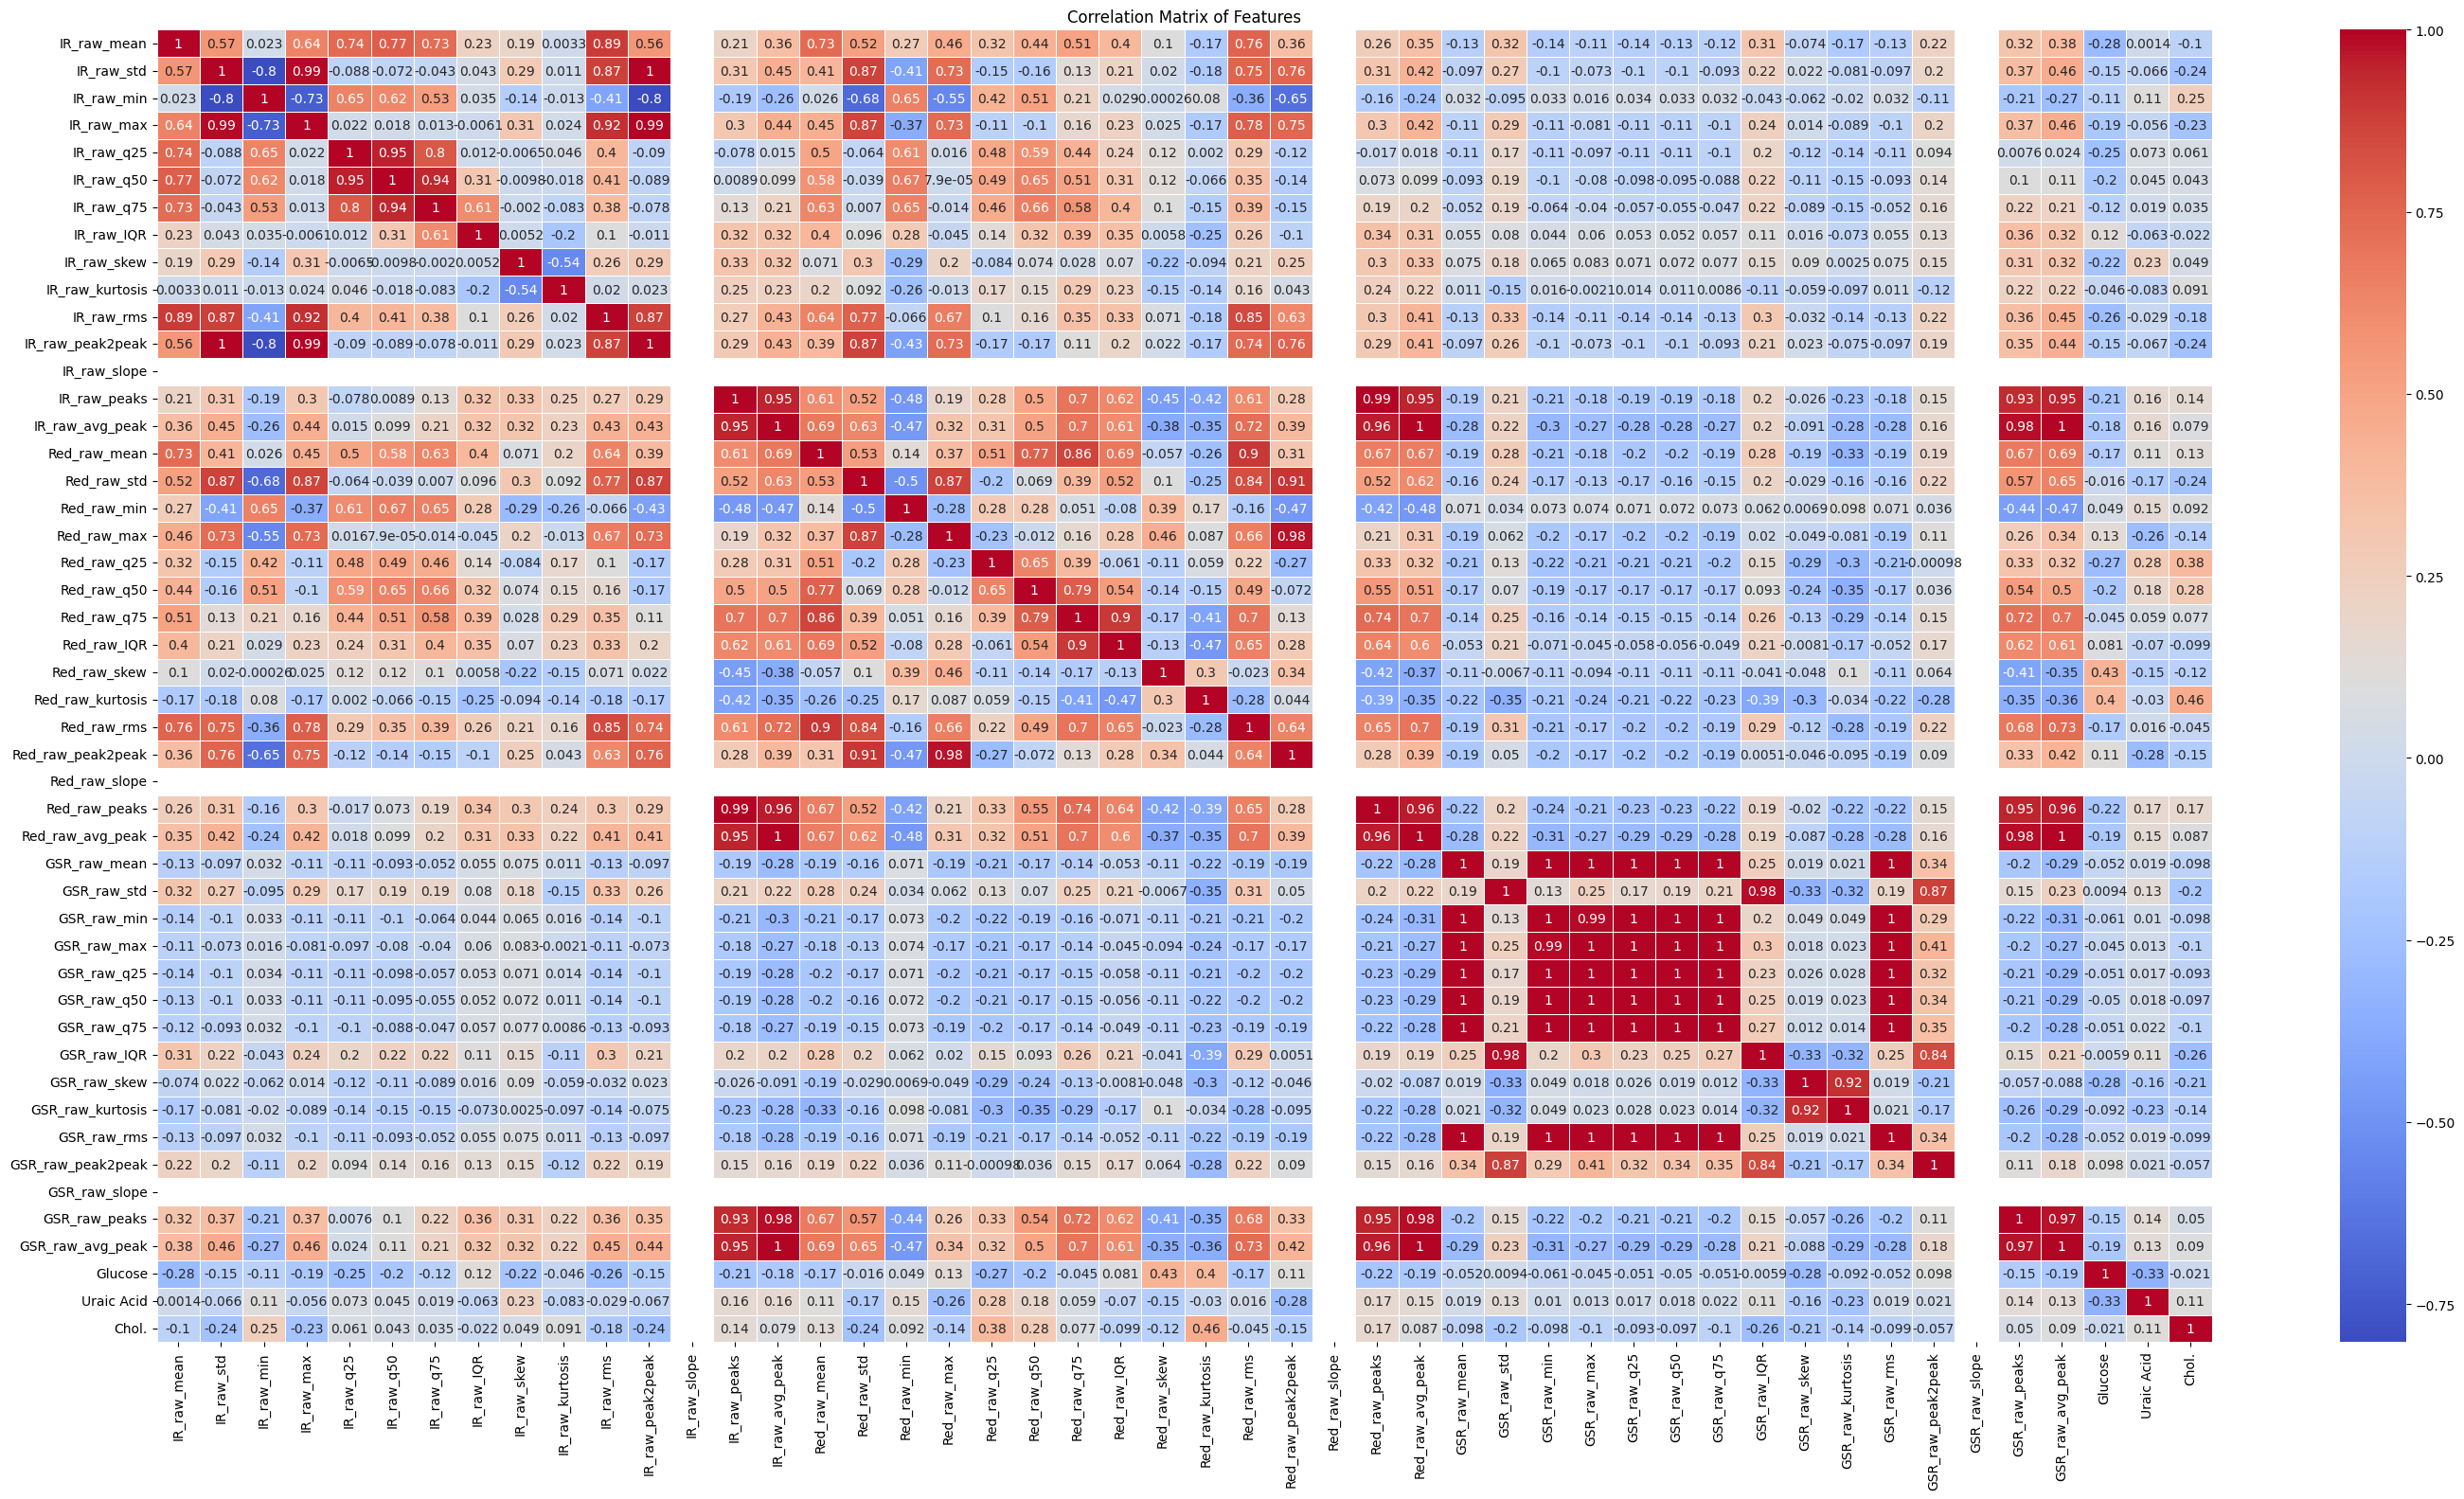

In [45]:
plt.figure(figsize=(35, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

In [46]:
correlations = correlation_matrix['Glucose'].drop('Glucose').sort_values(ascending=False).dropna()

print("Top 10 correlated features:")
print(correlations.head(10))
print("\nBottom 10 (most negative) correlated features:")
print(correlations.tail(10))

Top 10 correlated features:
Red_raw_skew         0.426609
Red_raw_kurtosis     0.400347
Red_raw_max          0.133168
IR_raw_IQR           0.124217
Red_raw_peak2peak    0.111909
GSR_raw_peak2peak    0.097947
Red_raw_IQR          0.081085
Red_raw_min          0.048559
GSR_raw_std          0.009377
GSR_raw_IQR         -0.005906
Name: Glucose, dtype: float64

Bottom 10 (most negative) correlated features:
IR_raw_q50      -0.201627
IR_raw_peaks    -0.210950
Red_raw_peaks   -0.216887
IR_raw_skew     -0.221258
IR_raw_q25      -0.246472
IR_raw_rms      -0.261259
Red_raw_q25     -0.271210
IR_raw_mean     -0.281943
GSR_raw_skew    -0.283816
Uraic Acid      -0.332205
Name: Glucose, dtype: float64


In [47]:
correlations_chol = correlation_matrix['Chol.'].drop('Chol.').sort_values(ascending=False).dropna()

print("Top 10 correlated features:")
print(correlations_chol.head(10))
print("\nBottom 10 (most negative) correlated features:")
print(correlations_chol.tail(10))

Top 10 correlated features:
Red_raw_kurtosis    0.461346
Red_raw_q25         0.380660
Red_raw_q50         0.280214
IR_raw_min          0.251118
Red_raw_peaks       0.168276
IR_raw_peaks        0.142064
Red_raw_mean        0.125347
Uraic Acid          0.110735
Red_raw_min         0.091613
IR_raw_kurtosis     0.090688
Name: Chol., dtype: float64

Bottom 10 (most negative) correlated features:
Red_raw_max         -0.142745
Red_raw_peak2peak   -0.150740
IR_raw_rms          -0.182341
GSR_raw_std         -0.203159
GSR_raw_skew        -0.208340
IR_raw_max          -0.228330
Red_raw_std         -0.235450
IR_raw_std          -0.237931
IR_raw_peak2peak    -0.241052
GSR_raw_IQR         -0.263025
Name: Chol., dtype: float64


In [48]:
correlations_urac = correlation_matrix['Uraic Acid'].drop('Uraic Acid').sort_values(ascending=False).dropna()

print("Top 10 correlated features:")
print(correlations_urac.head(10))
print("\nBottom 10 (most negative) correlated features:")
print(correlations_urac.tail(10))

Top 10 correlated features:
Red_raw_q25         0.279669
IR_raw_skew         0.230429
Red_raw_q50         0.178778
Red_raw_peaks       0.166496
IR_raw_peaks        0.161900
IR_raw_avg_peak     0.160097
Red_raw_min         0.154735
Red_raw_avg_peak    0.146445
GSR_raw_peaks       0.140334
GSR_raw_avg_peak    0.133846
Name: Uraic Acid, dtype: float64

Bottom 10 (most negative) correlated features:
IR_raw_peak2peak    -0.067086
Red_raw_IQR         -0.070251
IR_raw_kurtosis     -0.082686
Red_raw_skew        -0.145483
GSR_raw_skew        -0.162453
Red_raw_std         -0.171487
GSR_raw_kurtosis    -0.227257
Red_raw_max         -0.264916
Red_raw_peak2peak   -0.276478
Glucose             -0.332205
Name: Uraic Acid, dtype: float64


## Processing

In [ ]:
x1 = processing_data_numeric_df[["Red_raw_skew"]]
x2 = processing_data_numeric_df[["Red_raw_kurtosis"]]
x3 = processing_data_numeric_df[["IR_raw_IQR"]]
x4 = processing_data_numeric_df[["Red_raw_peak2peak"]]
## The negatively correlated ones
x5 = processing_data_numeric_df[["IR_raw_kurtosis"]]
x6 = processing_data_numeric_df[["IR_raw_avg_peak"]]
x7 = processing_data_numeric_df[["GSR_raw_min"]]
x8 = processing_data_numeric_df[["GSR_raw_q25"]]
x9 = processing_data_numeric_df[["GSR_raw_q50"]]
x10 = processing_data_numeric_df[["GSR_raw_mean"]]
x11 = processing_data_numeric_df[["GSR_raw_rms"]]
x12 = processing_data_numeric_df[["GSR_raw_max"]]
x13  = processing_data_numeric_df[["GSR_raw_q75"]]
# 2nd generation of nefgative correlated
#Glucose -
x14 = processing_data_numeric_df[["IR_raw_rms"]]
x15 = processing_data_numeric_df[["Red_raw_q25"]]
x16  = processing_data_numeric_df[["Red_raw_mean"]]
x17 = processing_data_numeric_df[["IR_raw_q25"]]
x18  = processing_data_numeric_df[["IR_raw_mean"]]
#Chol + 
x19  = processing_data_numeric_df[["Red_raw_q50"]]
x20 = processing_data_numeric_df[["Red_raw_peaks"]]
#URIC + 
x21 = processing_data_numeric_df[["IR_raw_skew"]]
#uric - 
x22  = processing_data_numeric_df[["GSR_raw_kurtosis"]]
x23 = processing_data_numeric_df[["Red_raw_max"]]


y = processing_data_numeric_df[["Glucose"]]
y2 = processing_data_numeric_df[["Chol."]]
y3 = processing_data_numeric_df[["Uraic Acid"]]

# random_size_set = np.random.randint(1, 3000, size=1)[0]
random_size_set = random.randint(1, 10000)


print(f"Random Seed {random_size_set}")
test_size_set = 0.2

y_train, y_test = train_test_split(y, test_size=test_size_set, random_state=random_size_set)
y2_train, y2_test = train_test_split(y2, test_size=test_size_set, random_state=random_size_set)
y3_train, y3_test = train_test_split(y3, test_size=test_size_set, random_state=random_size_set)

x1_train, x1_test = train_test_split(x1, test_size=test_size_set, random_state=random_size_set)
x2_train, x2_test = train_test_split(x2, test_size=test_size_set, random_state=random_size_set)
x3_train, x3_test = train_test_split(x3, test_size=test_size_set, random_state=random_size_set)
x4_train, x4_test = train_test_split(x4, test_size=test_size_set, random_state=random_size_set)
x5_train, x5_test = train_test_split(x5, test_size=test_size_set, random_state=random_size_set)
x6_train, x6_test = train_test_split(x6, test_size=test_size_set, random_state=random_size_set)
x7_train, x7_test = train_test_split(x7, test_size=test_size_set, random_state=random_size_set)
x8_train, x8_test = train_test_split(x8, test_size=test_size_set, random_state=random_size_set)
x9_train, x9_test = train_test_split(x9, test_size=test_size_set, random_state=random_size_set)
x10_train, x10_test = train_test_split(x10, test_size=test_size_set, random_state=random_size_set)
x11_train, x11_test = train_test_split(x11, test_size=test_size_set, random_state=random_size_set)
x12_train, x12_test = train_test_split(x12, test_size=test_size_set, random_state=random_size_set)
x13_train, x13_test = train_test_split(x13, test_size=test_size_set, random_state=random_size_set)
x14_train, x14_test = train_test_split(x14, test_size=test_size_set, random_state=random_size_set)
x15_train, x15_test = train_test_split(x15, test_size=test_size_set, random_state=random_size_set)
x16_train, x16_test = train_test_split(x16, test_size=test_size_set, random_state=random_size_set)
x17_train, x17_test = train_test_split(x17, test_size=test_size_set, random_state=random_size_set)
x18_train, x18_test = train_test_split(x18, test_size=test_size_set, random_state=random_size_set)
x19_train, x19_test = train_test_split(x19, test_size=test_size_set, random_state=random_size_set)
x20_train, x20_test = train_test_split(x20, test_size=test_size_set, random_state=random_size_set)
x21_train, x21_test = train_test_split(x21, test_size=test_size_set, random_state=random_size_set)
x22_train, x22_test = train_test_split(x22, test_size=test_size_set, random_state=random_size_set)
x23_train, x23_test = train_test_split(x23, test_size=test_size_set, random_state=random_size_set)
arbitary_limit = 10  #this is for training lol
arbitary_limit_test = 10

arbitary_limit_chol = 35    
arbitary_limit_test_chol = 40

arbitary_limit_uric = 2.0
arbitary_limit_test_uric = 2.0

arbitary_r_squared_limit = 0.1

features = [
    ('Skewness of Raw RED IR', x1_train, x1_test),
    ('Kurtosis of Raw RED IR', x2_train, x2_test),
    ('Interquatile of Raw Infrared', x3_train, x3_test),
    ('Peak to Peak of Raw RED IR', x4_train, x4_test),
    ('[-] Kurtosis of Raw Infrared', x5_train, x5_test),
    ('[-] Average Peak of Raw Infrared', x6_train, x6_test),
    ('[-] Minimum of Raw GSR ', x7_train, x7_test),
    ('[-] 25% Quartile of Raw GSR ', x8_train, x8_test),
    ('[-] 50% Quartile of Raw GSR', x9_train, x9_test),
    ('[-] Mean of Raw GSR', x10_train, x10_test),
    ('[-] Root Mean Square of Raw GSR', x11_train, x11_test),
    ('[-] Maximum of Raw GSR', x12_train, x12_test),
    ('[-] 75% Quartile of Raw GSR', x13_train, x13_test),
    ('[-] Root mean Square of Raw Infrared', x14_train, x14_test),
    ('[-] 25% Quartile of Raw Red', x15_train, x15_test),
    ('[-] Mean of Raw Red', x16_train, x16_test),
    ('[-] 25% Quartile of Raw Infrared', x17_train, x17_test),
    ('[-] Mean Quartile of Raw Infrared', x18_train, x18_test),
    ('50% Quartile of Raw Red', x19_train, x19_test),
    ('Peaks of Raw Red', x20_train, x20_test),
    ('Skew of Raw Infrared', x21_train, x21_test),
    ('[-] Kurtosis of Raw GSR', x22_train, x22_test),
    ('[-] Max of Raw Red', x23_train, x23_test)
]


Random Seed 9241


# Glucose

## Linear Regression Test

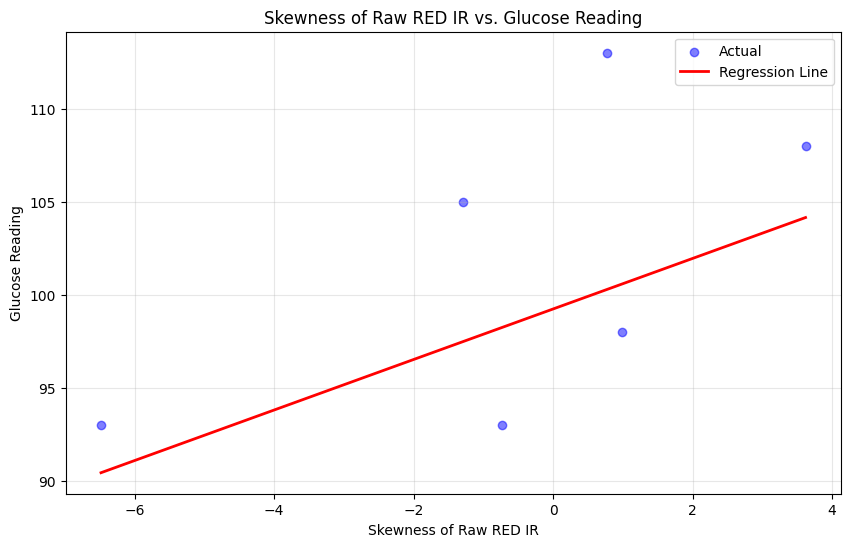

Feature: Skewness of Raw RED IR
Train data=

   MAE: 9.8319 mg/dL
   MSE: 171.3404 mg/dL
   RMSE: 13.0897 mg/dL
   R^2: 0.1755
Test data=

  Linear Regression MAE: 5.7503 mg/dL
  Linear Regression MSE: 45.7059 mg/dL
  Linear Regression RMSE: 6.7606 mg/dL
  Linear Regression R^2: 0.2013
  Coefficient: [1.35783696]
  Intercept: [99.22579451]
   Accuracy: 94.49%



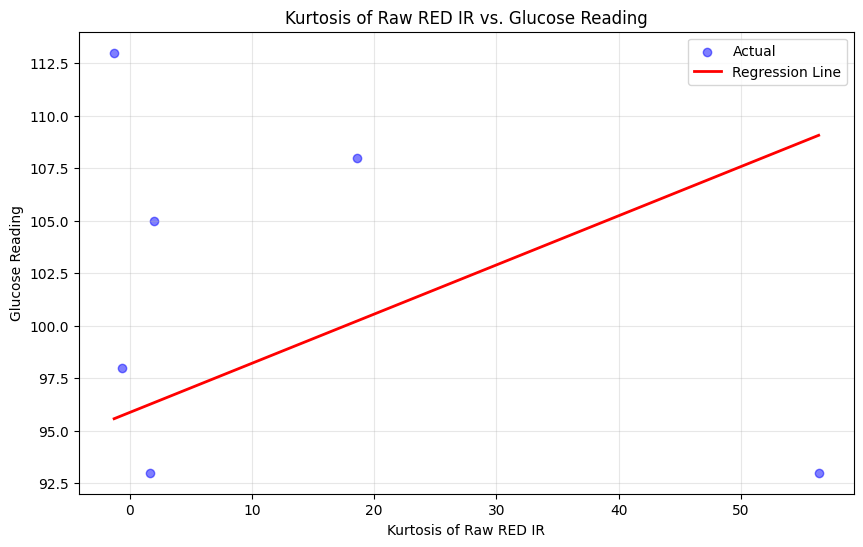

Feature: Kurtosis of Raw RED IR
Train data=

   MAE: 9.9746 mg/dL
   MSE: 157.2483 mg/dL
   RMSE: 12.5399 mg/dL
   R^2: 0.2433
Test data=

  Linear Regression MAE: 9.2449 mg/dL
  Linear Regression MSE: 118.8657 mg/dL
  Linear Regression RMSE: 10.9026 mg/dL
  Linear Regression R^2: -1.0773
  Coefficient: [0.23423147]
  Intercept: [95.86601962]
   Accuracy: 91.00%



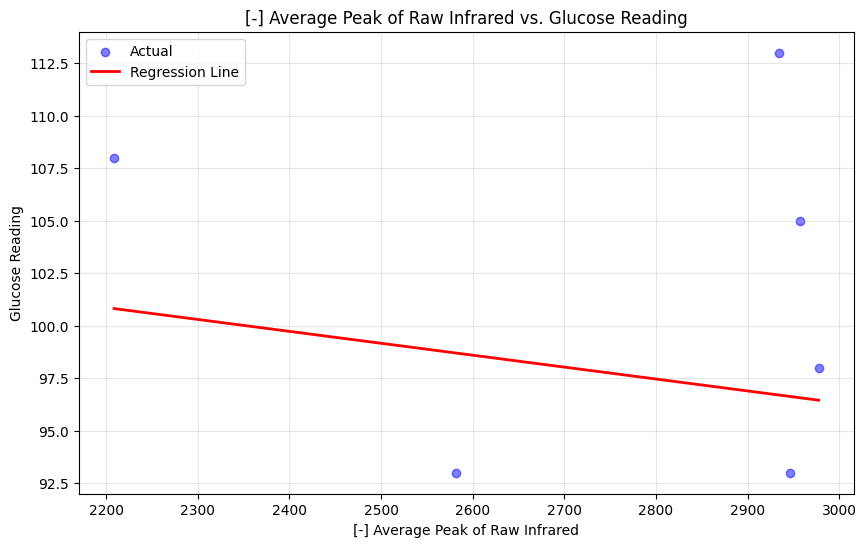

Feature: [-] Average Peak of Raw Infrared
Train data=

   MAE: 9.5500 mg/dL
   MSE: 198.4648 mg/dL
   RMSE: 14.0878 mg/dL
   R^2: 0.0450
Test data=

  Linear Regression MAE: 7.1314 mg/dL
  Linear Regression MSE: 72.7321 mg/dL
  Linear Regression RMSE: 8.5283 mg/dL
  Linear Regression R^2: -0.2710
  Coefficient: [-0.00567487]
  Intercept: [113.35129491]
   Accuracy: 93.21%



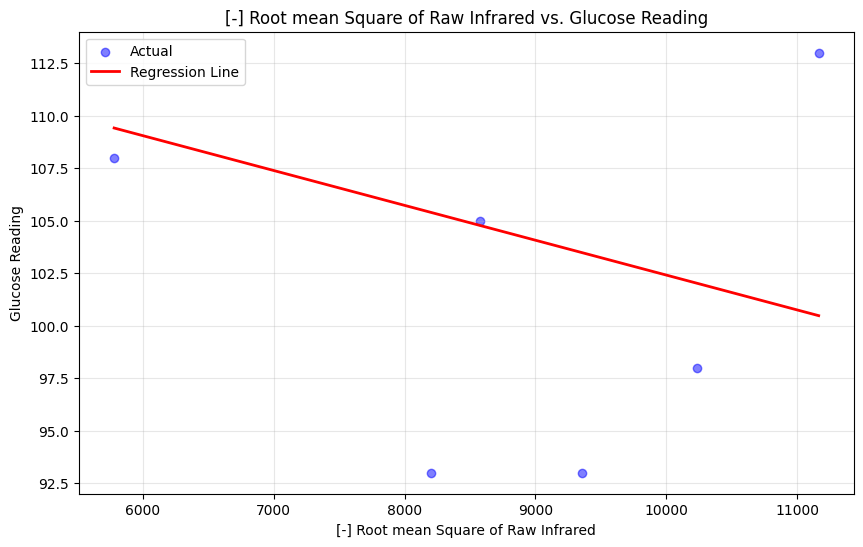

Feature: [-] Root mean Square of Raw Infrared
Train data=

   MAE: 9.8265 mg/dL
   MSE: 188.9463 mg/dL
   RMSE: 13.7458 mg/dL
   R^2: 0.0908
Test data=

  Linear Regression MAE: 6.8452 mg/dL
  Linear Regression MSE: 73.1149 mg/dL
  Linear Regression RMSE: 8.5507 mg/dL
  Linear Regression R^2: -0.2777
  Coefficient: [-0.00165946]
  Intercept: [119.00632699]
   Accuracy: 93.11%



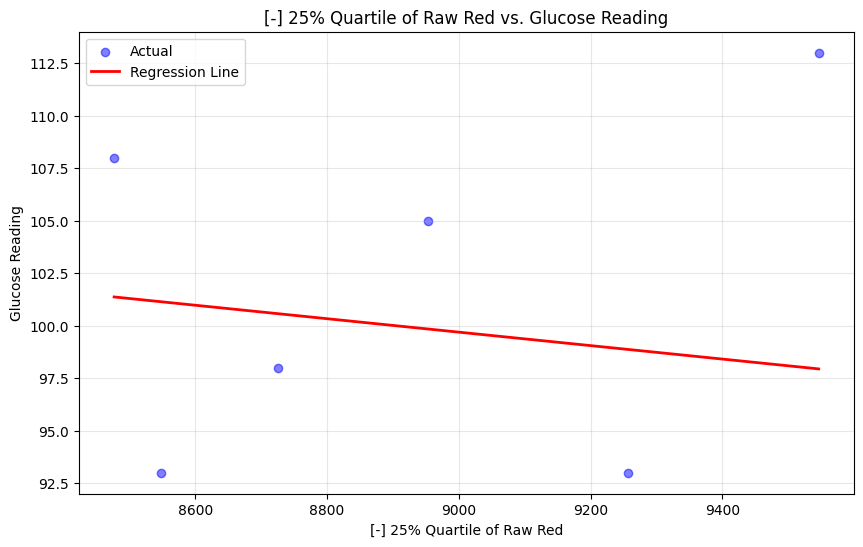

Feature: [-] 25% Quartile of Raw Red
Train data=

   MAE: 9.8574 mg/dL
   MSE: 188.9000 mg/dL
   RMSE: 13.7441 mg/dL
   R^2: 0.0910
Test data=

  Linear Regression MAE: 7.2384 mg/dL
  Linear Regression MSE: 67.4413 mg/dL
  Linear Regression RMSE: 8.2123 mg/dL
  Linear Regression R^2: -0.1786
  Coefficient: [-0.00320566]
  Intercept: [128.54473546]
   Accuracy: 92.99%



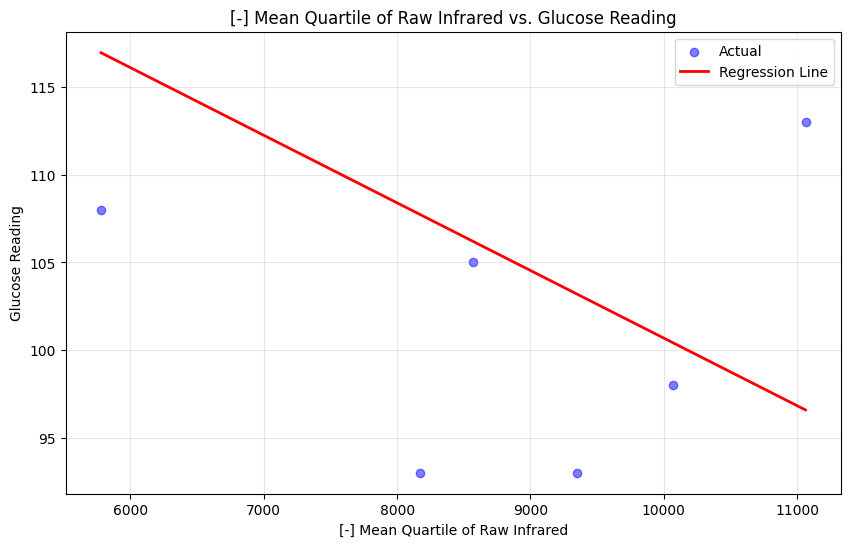

Feature: [-] Mean Quartile of Raw Infrared
Train data=

   MAE: 9.9770 mg/dL
   MSE: 179.4047 mg/dL
   RMSE: 13.3942 mg/dL
   R^2: 0.1367
Test data=

  Linear Regression MAE: 8.9884 mg/dL
  Linear Regression MSE: 112.9779 mg/dL
  Linear Regression RMSE: 10.6291 mg/dL
  Linear Regression R^2: -0.9744
  Coefficient: [-0.00385892]
  Intercept: [139.26997367]
   Accuracy: 91.13%



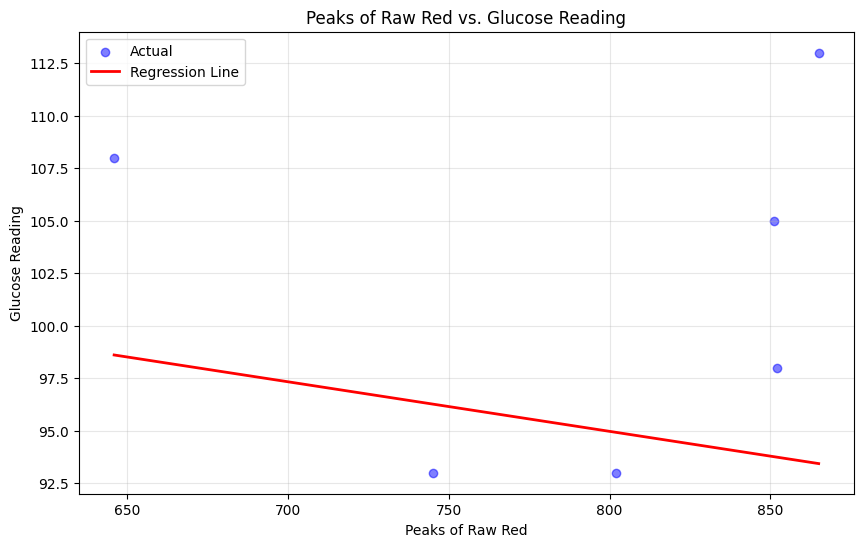

Feature: Peaks of Raw Red
Train data=

   MAE: 9.5251 mg/dL
   MSE: 191.3391 mg/dL
   RMSE: 13.8325 mg/dL
   R^2: 0.0793
Test data=

  Linear Regression MAE: 8.2738 mg/dL
  Linear Regression MSE: 104.9603 mg/dL
  Linear Regression RMSE: 10.2450 mg/dL
  Linear Regression R^2: -0.8343
  Coefficient: [-0.02361791]
  Intercept: [113.86418794]
   Accuracy: 92.23%



In [50]:
## Linear Regression


results_LR = {}
more_accurate = []
not_accurate = []

for feature, X_train, X_test in features:
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred_lr_train = lr.predict(X_train)
    mse_train = mean_squared_error(y_train, y_pred_lr_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
    r2_train = r2_score(y_train, y_pred_lr_train)
    mae_train = mean_absolute_error(y_train, y_pred_lr_train)
    
    y_pred_lr = lr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_lr)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2 = r2_score(y_test, y_pred_lr)
    mae = mean_absolute_error(y_test, y_pred_lr)
    y_test_1d = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()
    y_pred_1d = y_pred_lr.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100

    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_LR[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y_test, 
        'y_pred': y_pred_lr,
        'coefficients': lr.coef_,
        'intercept': lr.intercept_,
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
        'mape': mape
    }

for feature, metrics in results_LR.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    
    if feature == 'BPM + O2':
        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)

        
    else:
        if metrics['MAE'] < arbitary_limit_test and metrics['MAE_train'] < arbitary_limit:
            plt.figure(figsize=(10, 6))
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics
            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Glucose Reading')
            plt.title(f'{feature} vs. Glucose Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")

            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients'][0]}")
            print(f"  Intercept: {metrics['intercept']}")
            print(f"   Accuracy: {metrics['mape']:.2f}%")

            print(f"=====================================\n")
            
            current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # Clean feature name by replacing problematic characters
            def clean_filename(text):
                """Remove or replace characters that can break file paths"""
                # Replace common problematic characters
                invalid_chars = '<>:"/\\|?*'
                for char in invalid_chars:
                    text = text.replace(char, '')
                # Replace spaces and brackets with underscores
                text = text.replace(' ', '_').replace('[', '').replace(']', '')
                # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                text = ''.join(c for c in text if c.isalnum() or c in '_-')
                return text

            # Inside your loop where you save the file:
            fileName = f"Glucose-LinearRegression-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # Full path with folder
            # with open(f'GoodModels/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(lr, f)

## Random Forest

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

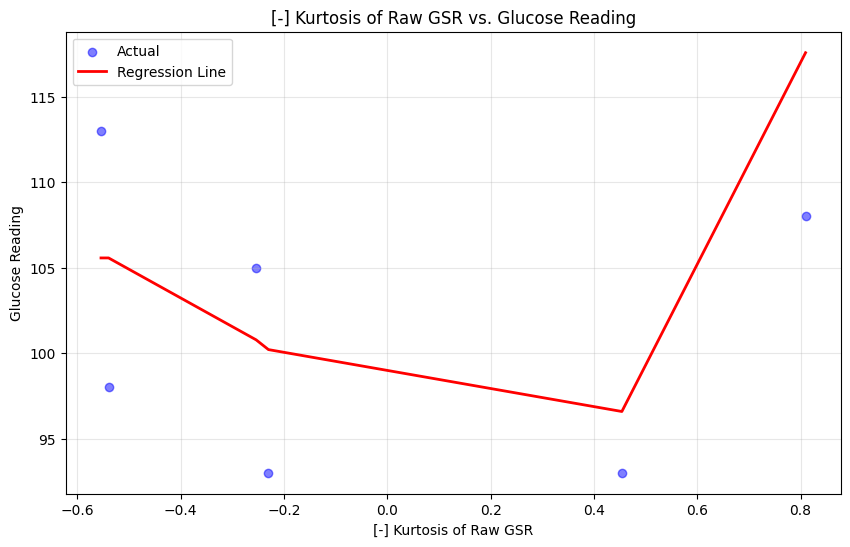

Feature: [-] Kurtosis of Raw GSR
Train data=

   MAE: 4.7145 mg/dL
   MSE: 42.6807 mg/dL
   RMSE: 6.5330 mg/dL
   R^2: 0.7946
Test data=

  Linear Regression MAE: 6.5950 mg/dL
  Linear Regression MSE: 47.7417 mg/dL
  Linear Regression RMSE: 6.9095 mg/dL
  Linear Regression R^2: 0.1657
  Coefficient: [0.00013062]
  Intercept: [100.01940796]
   Accuracy: 93.54%



In [51]:

results_RF = {}
more_accurate_RF = []
not_accurate_RF = []

for feature, X_train, X_test in features:
    RF = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
    RF.fit(X_train, y_train)
    
    y_pred_rf_train = RF.predict(X_train)
    mse_train = mean_squared_error(y_train, y_pred_rf_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
    r2_train = r2_score(y_train, y_pred_rf_train)
    mae_train = mean_absolute_error(y_train, y_pred_rf_train)
    
    y_pred_RF = RF.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_RF)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_RF))
    r2 = r2_score(y_test, y_pred_RF)
    mae = mean_absolute_error(y_test, y_pred_RF)
    y_test_1d = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()
    y_pred_1d = y_pred_RF.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100


    
    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_RF[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y_test, 
        'y_pred': y_pred_RF,
        'coefficients': lr.coef_,
        'intercept': lr.intercept_,
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
        'model': RF,
        'mape': mape,
    }

for feature, metrics in results_RF.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    if feature == 'BPM + O2':

        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.show()
        # plt.subplot(1, 2, 2)
        # residuals = metrics['y_test'] - metrics['y_pred']
        # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
        # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
        # plt.xlabel('Predicted Values')
        # plt.ylabel('Residuals')
        # plt.title('Residual Plot')
        # plt.grid(True, alpha=0.3)
        # plt.show()

        
    else:
    # Flatten if needed and get sort indices
        if (metrics['MAE'] < arbitary_limit_test and metrics['MAE_train'] < arbitary_limit) and metrics['R2'] > arbitary_r_squared_limit: 
            plt.figure(figsize=(10, 6))

            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Glucose Reading')
            plt.title(f'{feature} vs. Glucose Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")
            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients'][0]}")
            print(f"  Intercept: {metrics['intercept']}")
            print(f"   Accuracy: {metrics['mape']:.2f}%")

            print(f"=====================================\n")
            
            current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # Clean feature name by replacing problematic characters
            def clean_filename(text):
                """Remove or replace characters that can break file paths"""
                # Replace common problematic characters
                invalid_chars = '<>:"/\\|?*'
                for char in invalid_chars:
                    text = text.replace(char, '')
                # Replace spaces and brackets with underscores
                text = text.replace(' ', '_').replace('[', '').replace(']', '')
                # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                text = ''.join(c for c in text if c.isalnum() or c in '_-')
                return text

            # Inside your loop where you save the file:
            fileName = f"Glucose-RandomForest-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # Full path with folder
            # with open(f'GoodModels/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(metrics['model'],f)
                
            # # # cmodel = emlearn.convert(metrics['model'], method='inline')
            # # cmodel.save(file=f'GoodModels/RF/{fileName}.h', name='rf_gsr')


## Polynomial

DEGREE  1


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


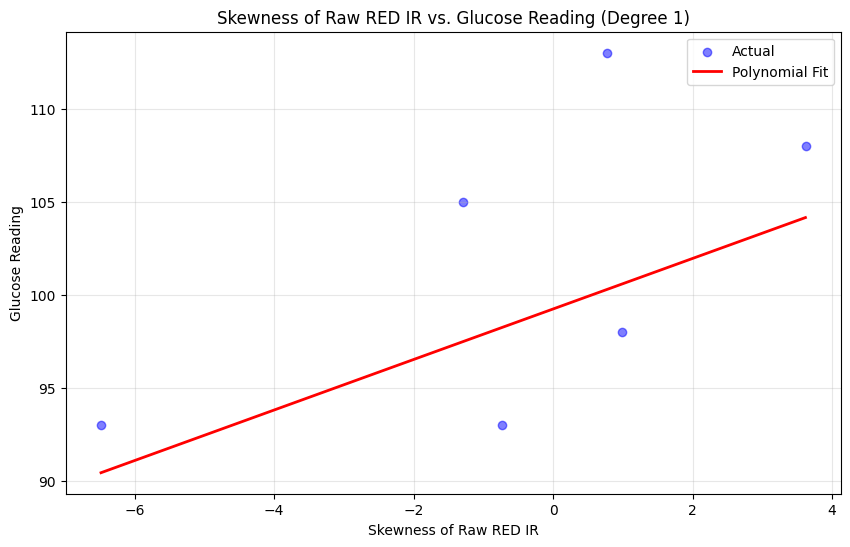

Feature: Skewness of Raw RED IR
Train data=

   MAE: 9.8319 mg/dL
   MSE: 171.3404 mg/dL
   RMSE: 13.0897 mg/dL
   R^2: 0.1755
Test data=

  Linear Regression MAE: 5.7503 mg/dL
  Linear Regression MSE: 45.7059 mg/dL
  Linear Regression RMSE: 6.7606 mg/dL
  Linear Regression R^2: 0.2013
  Coefficient: [0.         1.35783696]
  Intercept: [99.22579451]
  Coefficients: [[0.         1.35783696]]
   Accuracy: 94.49%

DEGREE  2
DEGREE  3
DEGREE  4
DEGREE  5
DEGREE  6
DEGREE  7
DEGREE  8


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


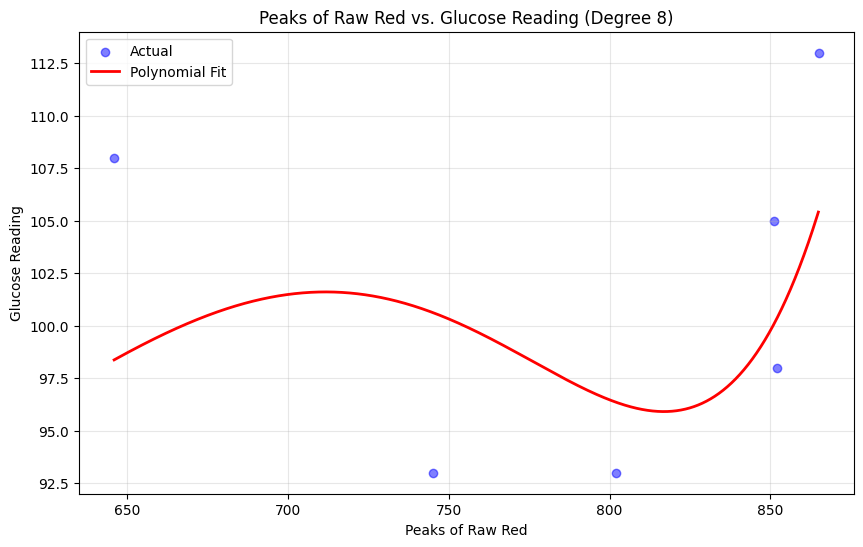

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Feature: Peaks of Raw Red
Train data=

   MAE: 9.7204 mg/dL
   MSE: 152.1418 mg/dL
   RMSE: 12.3346 mg/dL
   R^2: 0.2679
Test data=

  Linear Regression MAE: 5.9077 mg/dL
  Linear Regression MSE: 41.4959 mg/dL
  Linear Regression RMSE: 6.4417 mg/dL
  Linear Regression R^2: 0.2748
  Coefficient: [ 0.00000000e+00  2.21939508e-16 -1.07150039e-18 -4.24091617e-16
 -1.22501437e-13 -2.13475797e-11  8.07956748e-14 -1.02900715e-16
  4.38890851e-20]
  Intercept: [128.07227436]
  Coefficients: [[ 0.00000000e+00  2.21939508e-16 -1.07150039e-18 -4.24091617e-16
  -1.22501437e-13 -2.13475797e-11  8.07956748e-14 -1.02900715e-16
   4.38890851e-20]]
   Accuracy: 94.25%

DEGREE  9


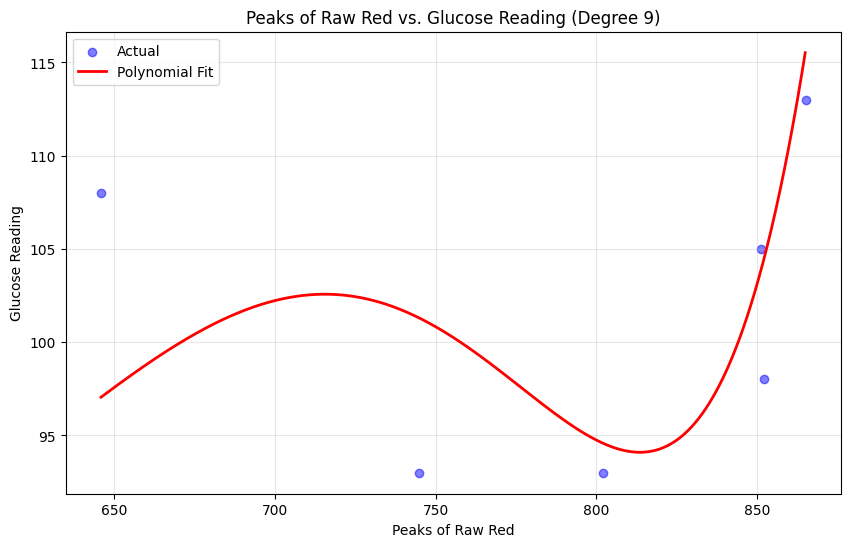

Feature: Peaks of Raw Red
Train data=

   MAE: 9.5959 mg/dL
   MSE: 150.2823 mg/dL
   RMSE: 12.2590 mg/dL
   R^2: 0.2768
Test data=

  Linear Regression MAE: 5.1832 mg/dL
  Linear Regression MSE: 40.1336 mg/dL
  Linear Regression RMSE: 6.3351 mg/dL
  Linear Regression R^2: 0.2986
  Coefficient: [ 0.00000000e+00  2.89726480e-19 -5.29182813e-23 -2.68137524e-21
 -9.63931628e-19 -2.67549521e-16 -4.57884267e-14  1.76492640e-16
 -2.27694393e-19  9.80689224e-23]
  Intercept: [123.00005783]
  Coefficients: [[ 0.00000000e+00  2.89726480e-19 -5.29182813e-23 -2.68137524e-21
  -9.63931628e-19 -2.67549521e-16 -4.57884267e-14  1.76492640e-16
  -2.27694393e-19  9.80689224e-23]]
   Accuracy: 94.87%



In [52]:
## POLUNOMIAL

results_PL = {}
emd_result_PL = {}
degree = 1

for feature, X_train, X_test in features:
    emd_result_PL[feature] = {}
    
for x in range(1, 10):
    print("DEGREE ", x)
    print("==" *50)
    for feature, X_train, X_test in features:
        # emd_result_PL[feature] = {}
        PL = PolynomialFeatures(degree=x)
        # PL.fit(X_train, y_train)
        X_train_poly = PL.fit_transform(X_train)
        X_test_poly = PL.transform(X_test)
        lr = LinearRegression()
        

        
        
        lr.fit(X_train_poly, y_train)
        
        y_pred_pl_train = lr.predict(X_train_poly)
        mse_train = mean_squared_error(y_train, y_pred_pl_train)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_pl_train))
        r2_train = r2_score(y_train, y_pred_pl_train)
        mae_train = mean_absolute_error(y_train, y_pred_pl_train)
        
        
        y_pred_PL = lr.predict(X_test_poly)
        mse = mean_squared_error(y_test, y_pred_PL)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred_PL))
        r2 = r2_score(y_test, y_pred_PL)
        mae = mean_absolute_error(y_test, y_pred_PL)
        y_test_1d = y_test.values.ravel() if hasattr(y_test, 'values') else y_test.ravel()
        y_pred_1d = y_pred_PL.ravel()
        mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100

        # if r2 > 0.75:
        #     more_accurate_NN.append(feature)   
        # else:
        #     not_accurate_NN.append(feature)
        
        results_PL[feature] = {
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
            'X_test': X_test, 
            'y_test': y_test, 
            'y_pred': y_pred_PL,
            'coefficients': lr.coef_,
            'intercept': lr.intercept_,
            'MAE_train': mae_train,
            'MSE_train': mse_train,
            'RMSE_train': rmse_train,
            'R2_train': r2_train,
            'model': lr,
            'mape': mape
        }
        emd_result_PL[feature][x] = {
            'degree': x,
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
        }

    for feature, metrics in results_PL.items():
        if (metrics['MAE'] < arbitary_limit_test and metrics['MAE_train'] < arbitary_limit) and metrics['R2'] > arbitary_r_squared_limit: 

        
            plt.figure(figsize=(10, 6))
            
            # Convert to numpy array and sort for plotting the regression line
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
            y_pred_array = metrics['y_pred']
            
            if feature == 'BPM + O2':
                # For multiple features: Show Actual vs Predicted plot
                # plt.subplot(1, 2, 1)
                plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
                plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                        [metrics['y_test'].min(), metrics['y_test'].max()], 
                        'r--', lw=2)
                plt.xlabel('Actual Values')
                plt.ylabel('Predicted Values')
                plt.title(f'{feature}\nActual vs Predicted')
                plt.grid(True, alpha=0.3)
                plt.show()
                # Show residuals plot
                # plt.subplot(1, 2, 2)
                # residuals = metrics['y_test'] - metrics['y_pred']
                # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
                # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
                # plt.xlabel('Predicted Values')
                # plt.ylabel('Residuals')
                # plt.title('Residual Plot')
                # plt.grid(True, alpha=0.3)
                
            else:
                
                X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
                
                # Create a range of X values from min to max with 0.1 spacing
                X_smooth = np.arange(X_test_flat.min(), X_test_flat.max(), 0.1).reshape(-1, 1)
                
                # Transform the smooth X values using the same polynomial features
                X_smooth_poly = PL.transform(X_smooth)
                
                # Predict using the trained model
                y_smooth_pred = metrics['model'].predict(X_smooth_poly)
                
                # Plot the actual data points
                plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
                
                # Plot the smooth polynomial curve
                plt.plot(X_smooth, y_smooth_pred, color='red', label='Polynomial Fit', linewidth=2)
                
                plt.xlabel(feature)
                plt.ylabel('Glucose Reading')
                plt.title(f'{feature} vs. Glucose Reading (Degree {x})')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()
            
                print(f"Feature: {feature}")
                print(f"Train data=\n")
                print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
                print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
                print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
                print(f"   R^2: {metrics['R2_train']:.4f}")
                print(f"Test data=\n")
                print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
                print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
                print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
                print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
                print(f"  Coefficient: {metrics['coefficients'][0]}")
                print(f"  Intercept: {metrics['intercept']}")
                print(f"  Coefficients: {metrics['coefficients']}")
                print(f"   Accuracy: {metrics['mape']:.2f}%")

                print(f"=====================================\n")
                
                current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

                # Clean feature name by replacing problematic characters
                def clean_filename(text):
                    """Remove or replace characters that can break file paths"""
                    # Replace common problematic characters
                    invalid_chars = '<>:"/\\|?*'
                    for char in invalid_chars:
                        text = text.replace(char, '')
                    # Replace spaces and brackets with underscores
                    text = text.replace(' ', '_').replace('[', '').replace(']', '')
                    # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                    text = ''.join(c for c in text if c.isalnum() or c in '_-')
                    return text

                # Inside your loop where you save the file:
                fileName = f"Glucose-Polynomial-{clean_filename(feature)}-{round(metrics['MAE'])}-Degree-{x}-{current_date}"

                # Full path with folder
                # with open(f'GoodModels/{fileName}.pkl', 'wb') as f:
                #     pickle.dump(metrics['model'], f)
                    
                # cmodel = emlearn.convert(metrics['model'], method='inline')
                # cmodel.save(file=f'{fileName}.h', name='rf_gsr')
                
            

    

## Voting Model

y_pred_rf shape: (6,)
y_pred_lr shape: (6,)
[ 97.3913203  107.3040912  110.59414786 102.27184798 104.98993666
  98.93512591]
Random Forest MAE: 6.5950
Poly+Linear MAE:    5.1832
Ensemble MAE:       3.8577
Ensemble R²:        0.6590
Ensemble MAPE:          3.93%
Ensemble Accuracy:      96.07%


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


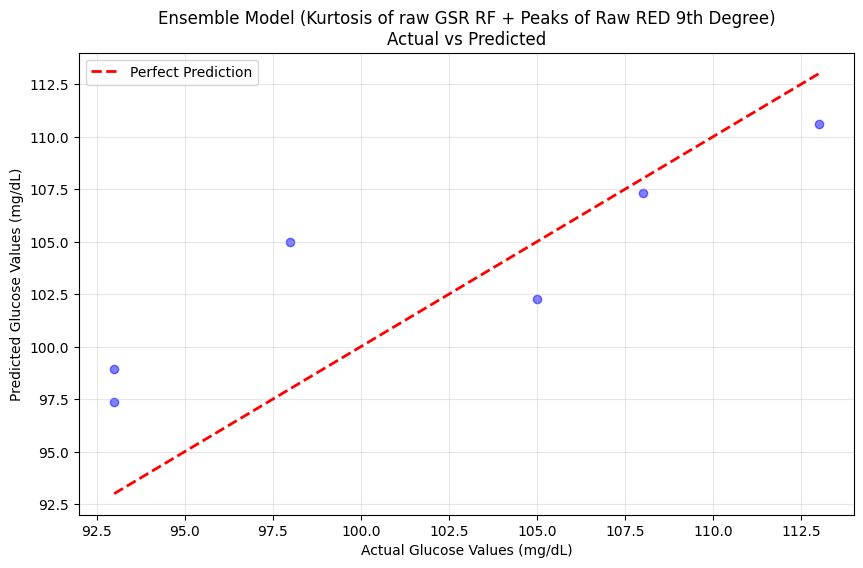

In [53]:

#

# --- Model 1: Random Forest on Peak to Peak of Raw RED IR ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x22_train, y_train)
y_pred_rf_ensemble = rf.predict(x22_test)

# --- Model 2: Polynomial + Linear Regression on Peak to Peak of Raw RED IR ---
pl = PolynomialFeatures(degree=9)  
X_train_poly = pl.fit_transform(x20_train)
X_test_poly = pl.transform(x20_test)
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr_ensemble = lr.predict(X_test_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y_test.values.ravel()   

#--dhdhehehhehfhe MAPE
def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


mape_rf = calculate_mape(y_test_flat, y_pred_rf_ensemble)
mape_lr = calculate_mape(y_test_flat, y_pred_lr_ensemble)
mape_ensemble = calculate_mape(y_test_flat, y_pred_ensemble)
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")
print(f"Ensemble MAPE:          {mape_ensemble:.2f}%")
print(f"Ensemble Accuracy:      {100 - mape_ensemble:.2f}%")

##Showing

plt.figure(figsize=(10, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Glucose Values (mg/dL)')
plt.ylabel('Predicted Glucose Values (mg/dL)')
plt.title(f'Ensemble Model (Kurtosis of raw GSR RF + Peaks of Raw RED 9th Degree)\nActual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
y_pred_ensemble

array([ 97.3913203 , 107.3040912 , 110.59414786, 102.27184798,
       104.98993666,  98.93512591])

In [55]:
y_test

,Glucose
0,93
0,108
0,113
0,105
0,98
0,93


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


y_pred_rf shape: (20,)
y_pred_lr shape: (20,)
[101.86571142 106.95953613 104.74348746 108.41553088 102.26480949
  94.05805074 119.81661527  99.09099795  94.00532859 101.19963617
  99.32177028 104.2539468  115.78664473  98.27032859  90.81927801
 101.24646948 100.84032707 101.54438429  97.50395868 111.53818798]
Random Forest MAE: 4.7145
Poly+Linear MAE:    9.5959
Ensemble MAE:       6.2593
Ensemble R²:        0.6222


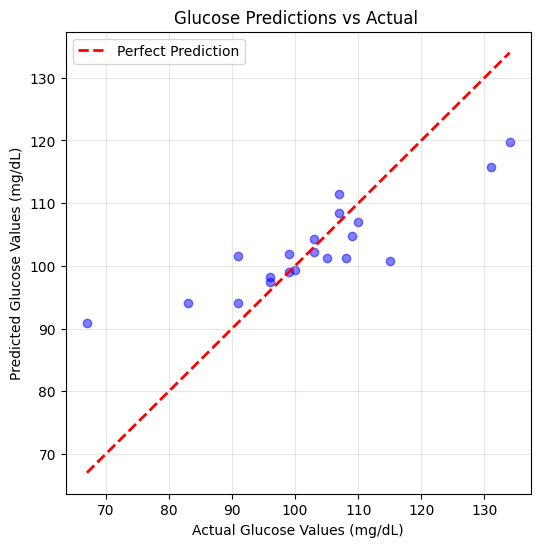

In [56]:

#

# --- Model 1: Random Forest on 25% Quartile of Raw GSR ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x22_train, y_train)
y_pred_rf_ensemble = rf.predict(x22_train)

# --- Model 2: Polynomial + Linear Regression on Average Peak of Raw Infrared ---
pl = PolynomialFeatures(degree=9)   # 'x' should be defined (e.g., degree=2)
X_train_poly = pl.fit_transform(x20_train)
X_test_poly = pl.transform(x20_test)
lr = LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred_lr_ensemble = lr.predict(X_train_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y_train.values.ravel()   
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")

##Showing

plt.figure(figsize=(6, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Glucose Values (mg/dL)')
plt.ylabel('Predicted Glucose Values (mg/dL)')
plt.title(f'Glucose Predictions vs Actual ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cholestrol Processing

## Linear

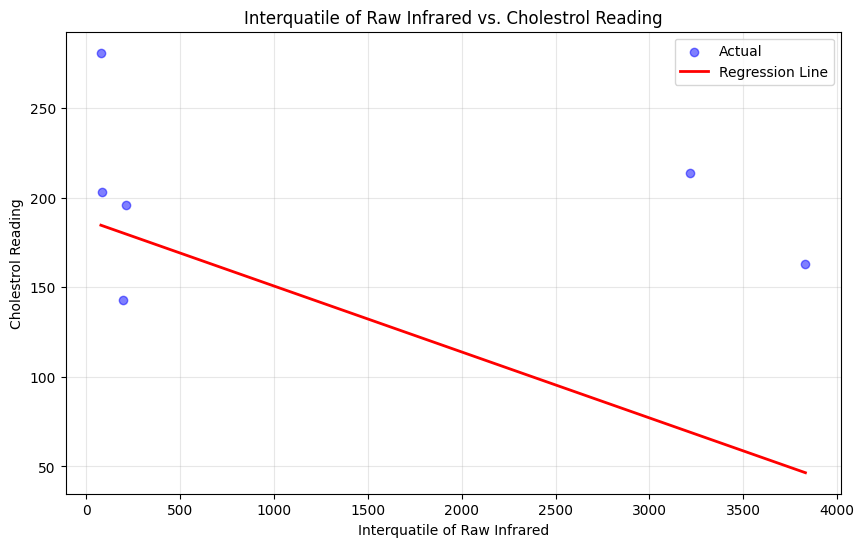

Feature: Interquatile of Raw Infrared
Train data=

   MAE: 36.6505 mg/dL
   MSE: 2208.7622 mg/dL
   RMSE: 46.9975 mg/dL
   R^2: 0.0213
Test data=

  Linear Regression MAE: 71.6084 mg/dL
  Linear Regression MSE: 7632.8348 mg/dL
  Linear Regression RMSE: 87.3661 mg/dL
  Linear Regression R^2: -3.0173
  Coefficient: [-0.03680889]
  Intercept: [187.54821215]



In [57]:
## Linear Regression
features = [
    ('Skewness of Raw RED IR', x1_train, x1_test),
    ('Kurtosis of Raw RED IR', x2_train, x2_test),
    ('Interquatile of Raw Infrared', x3_train, x3_test),
    ('Peak to Peak of Raw RED IR', x4_train, x4_test),
    ('[-] Kurtosis of Raw Infrared', x5_train, x5_test),
    ('[-] Average Peak of Raw Infrared', x6_train, x6_test),
    ('[-] Minimum of Raw GSR ', x7_train, x7_test),
    ('[-] 25% Quartile of Raw GSR ', x8_train, x8_test),
    ('[-] 50% Quartile of Raw GSR', x9_train, x9_test),
    ('[-] Mean of Raw GSR', x10_train, x10_test),
    ('[-] Root Mean Square of Raw GSR', x11_train, x11_test),
    ('[-] Maximum of Raw GSR', x12_train, x12_test),
    ('[-] 75% Quartile of Raw GSR', x13_train, x13_test)
    
]

results_LR = {}
more_accurate = []
not_accurate = []

for feature, X_train, X_test in features:
    lr = LinearRegression()
    lr.fit(X_train, y2_train)
    
    y2_pred_lr_train = lr.predict(X_train)
    mse_train = mean_squared_error(y2_train, y2_pred_lr_train)
    rmse_train = np.sqrt(mean_squared_error(y2_train, y2_pred_lr_train))
    r2_train = r2_score(y2_train, y2_pred_lr_train)
    mae_train = mean_absolute_error(y2_train, y2_pred_lr_train)
    
    y2_pred_lr = lr.predict(X_test)
    mse = mean_squared_error(y2_test, y2_pred_lr)
    rmse = np.sqrt(mean_squared_error(y2_test, y2_pred_lr))
    r2 = r2_score(y2_test, y2_pred_lr)
    mae = mean_absolute_error(y2_test, y2_pred_lr)
    y_test_1d = y2_test.values.ravel() if hasattr(y3_test, 'values') else y2_test.ravel()
    y_pred_1d = y2_pred_lr.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100
    
    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_LR[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y2_test, 
        'y_pred': y2_pred_lr,
        'coefficients': lr.coef_,
        'intercept': lr.intercept_,
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
            'mape': mape
    }

for feature, metrics in results_LR.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    
    if feature == 'BPM + O2':
        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)

        
    else:
        if metrics['MAE'] > arbitary_limit_test_chol and metrics['MAE_train'] > arbitary_limit_chol:
            plt.figure(figsize=(10, 6))
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics
            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Cholestrol Reading')
            plt.title(f'{feature} vs. Cholestrol Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")
            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients'][0]}")
            print(f"  Intercept: {metrics['intercept']}")
            print(f"=====================================\n")
            
            # current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # # Clean feature name by replacing problematic characters
            # def clean_filename(text):
            #     """Remove or replace characters that can break file paths"""
            #     # Replace common problematic characters
            #     invalid_chars = '<>:"/\\|?*'
            #     for char in invalid_chars:
            #         text = text.replace(char, '')
            #     # Replace spaces and brackets with underscores
            #     text = text.replace(' ', '_').replace('[', '').replace(']', '')
            #     # Remove any other non-alphanumeric characters (keep underscores and hyphens)
            #     text = ''.join(c for c in text if c.isalnum() or c in '_-')
            #     return text

            # # Inside your loop where you save the file:
            # fileName = f"LinearRegression-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # # Full path with folder
            # with open(f'GoodModels/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(metrics['model'], f)

## Random Forest

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

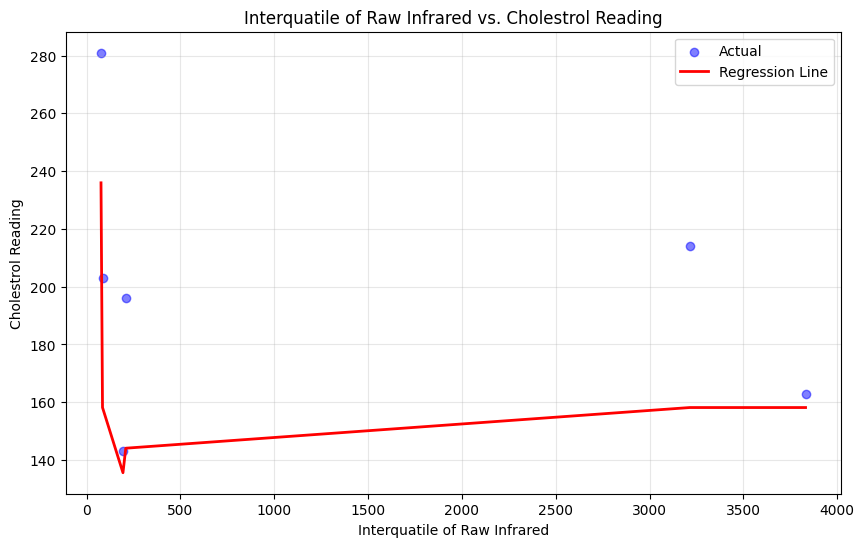

Feature: Interquatile of Raw Infrared
Train data=

   MAE: 19.5380 mg/dL
   MSE: 608.7117 mg/dL
   RMSE: 24.6721 mg/dL
   R^2: 0.7303
Test data=

  Linear Regression MAE: 34.9983 mg/dL
  Linear Regression MSE: 1656.3255 mg/dL
  Linear Regression RMSE: 40.6980 mg/dL
  Linear Regression R^2: 0.1282
  Coefficient: <bound method BaseForest.decision_path of RandomForestRegressor(random_state=9241)>
   Accuracy: 83.52%



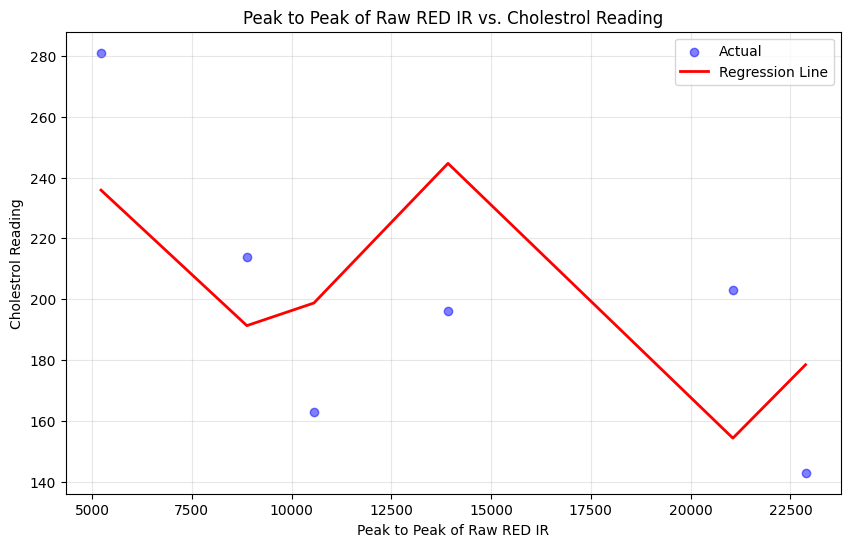

Feature: Peak to Peak of Raw RED IR
Train data=

   MAE: 15.6665 mg/dL
   MSE: 426.5832 mg/dL
   RMSE: 20.6539 mg/dL
   R^2: 0.8110
Test data=

  Linear Regression MAE: 39.3900 mg/dL
  Linear Regression MSE: 1636.9598 mg/dL
  Linear Regression RMSE: 40.4594 mg/dL
  Linear Regression R^2: 0.1384
  Coefficient: <bound method BaseForest.decision_path of RandomForestRegressor(random_state=9241)>
   Accuracy: 79.64%



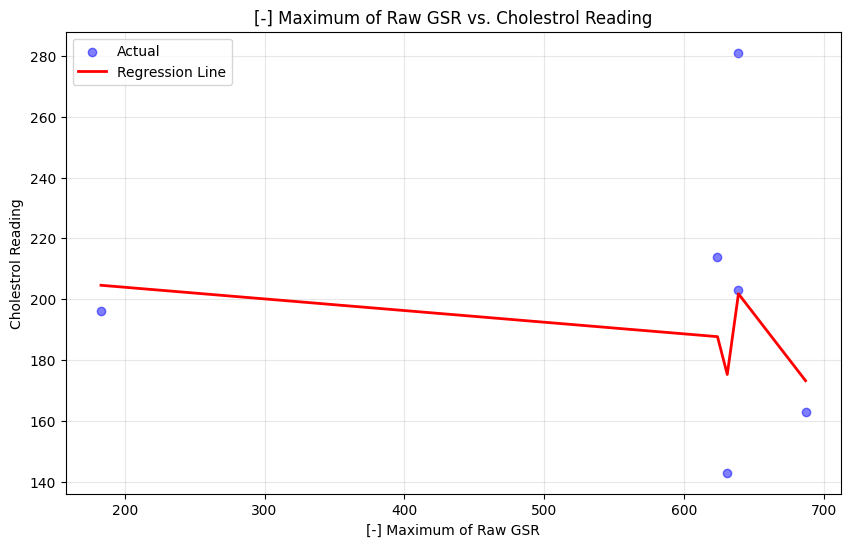

Feature: [-] Maximum of Raw GSR
Train data=

   MAE: 19.1630 mg/dL
   MSE: 634.9607 mg/dL
   RMSE: 25.1984 mg/dL
   R^2: 0.7186
Test data=

  Linear Regression MAE: 26.3000 mg/dL
  Linear Regression MSE: 1364.3147 mg/dL
  Linear Regression RMSE: 36.9366 mg/dL
  Linear Regression R^2: 0.2819
  Coefficient: <bound method BaseForest.decision_path of RandomForestRegressor(random_state=9241)>
   Accuracy: 87.62%



In [58]:

results_RF = {}
more_accurate_RF = []
not_accurate_RF = []

for feature, X_train, X_test in features:
    RF = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
    RF.fit(X_train, y2_train)
    
    y_pred_rf_train = RF.predict(X_train)
    mse_train = mean_squared_error(y2_train, y_pred_rf_train)
    rmse_train = np.sqrt(mean_squared_error(y2_train, y_pred_rf_train))
    r2_train = r2_score(y2_train, y_pred_rf_train)
    mae_train = mean_absolute_error(y2_train, y_pred_rf_train)
    
    y_pred_RF = RF.predict(X_test)
    mse = mean_squared_error(y2_test, y_pred_RF)
    rmse = np.sqrt(mean_squared_error(y2_test, y_pred_RF))
    r2 = r2_score(y2_test, y_pred_RF)
    mae = mean_absolute_error(y2_test, y_pred_RF)
    y_test_1d = y2_test.values.ravel() if hasattr(y3_test, 'values') else y2_test.ravel()
    y_pred_1d = y_pred_RF.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100
    
    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_RF[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y2_test, 
        'y_pred': y_pred_RF,
        'coefficients': RF.decision_path,
        'model': RF,
        
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
            'mape': mape
    }

for feature, metrics in results_RF.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    if feature == 'BPM + O2':

        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.show()
        # plt.subplot(1, 2, 2)
        # residuals = metrics['y_test'] - metrics['y_pred']
        # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
        # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
        # plt.xlabel('Predicted Values')
        # plt.ylabel('Residuals')
        # plt.title('Residual Plot')
        # plt.grid(True, alpha=0.3)
        # plt.show()

        
    else:
    # Flatten if needed and get sort indices
        if metrics['MAE'] < arbitary_limit_test_chol and metrics['MAE_train'] < arbitary_limit_chol and metrics['R2'] > arbitary_r_squared_limit:
            plt.figure(figsize=(10, 6))

            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Cholestrol Reading')
            plt.title(f'{feature} vs. Cholestrol Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")
            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients']}")
            print(f"   Accuracy: {metrics['mape']:.2f}%")

            print(f"=====================================\n")
            
            current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # Clean feature name by replacing problematic characters
            def clean_filename(text):
                """Remove or replace characters that can break file paths"""
                # Replace common problematic characters
                invalid_chars = '<>:"/\\|?*'
                for char in invalid_chars:
                    text = text.replace(char, '')
                # Replace spaces and brackets with underscores
                text = text.replace(' ', '_').replace('[', '').replace(']', '')
                # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                text = ''.join(c for c in text if c.isalnum() or c in '_-')
                return text

            # Inside your loop where you save the file:
            fileName = f"Chol-RandomForest-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # Full path with folder
            # with open(f'GoodModels/UricAcid/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(metrics['model'],f)
                
            # # cmodel = emlearn.convert(metrics['model'], method='inline')
            # cmodel.save(file=f'GoodModels/Chol/RF/{fileName}.h', name='rf_gsr')
            
            

## Polynomial?

DEGREE  1
DEGREE  2
DEGREE  3
DEGREE  4


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


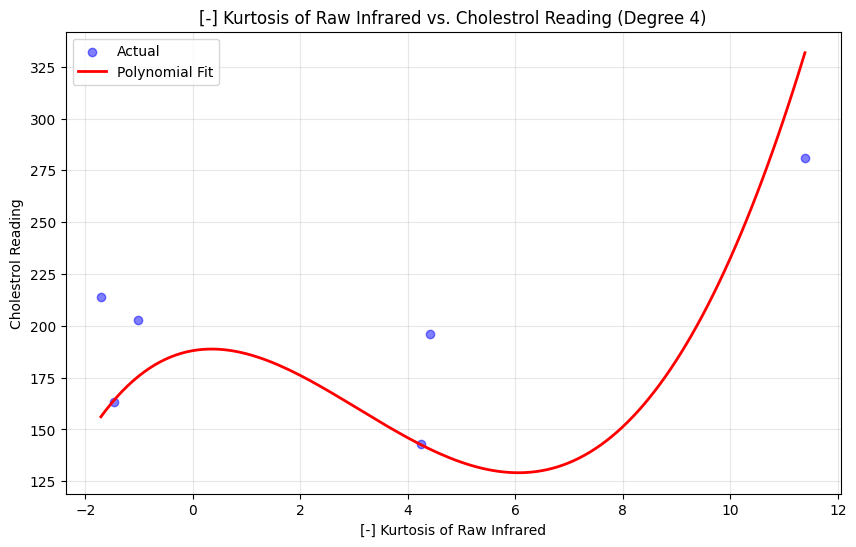

Feature: [-] Kurtosis of Raw Infrared
Train data=

   MAE: 31.8390 mg/dL
   MSE: 1970.7260 mg/dL
   RMSE: 44.3929 mg/dL
   R^2: 0.1267
Test data=

  Linear Regression MAE: 32.3837 mg/dL
  Linear Regression MSE: 1644.2692 mg/dL
  Linear Regression RMSE: 40.5496 mg/dL
  Linear Regression R^2: 0.1346
  Coefficient: [ 0.          4.44063723 -6.82298462  0.82880367 -0.01462045]
  Intercept: [188.01452453]
   Accuracy: 85.27%

DEGREE  5
DEGREE  6
DEGREE  7
DEGREE  8
DEGREE  9


In [59]:
## POLUNOMIAL

results_PL = {}
emd_result_PL = {}
degree = 1

for feature, X_train, X_test in features:
    emd_result_PL[feature] = {}
    
for x in range(1, 10):
    print("DEGREE ", x)
    print("==" *50)
    for feature, X_train, X_test in features:
        # emd_result_PL[feature] = {}
        PL = PolynomialFeatures(degree=x)
        # PL.fit(X_train, y_train)
        X_train_poly = PL.fit_transform(X_train)
        X_test_poly = PL.transform(X_test)
        lr = LinearRegression()
        

        
        
        lr.fit(X_train_poly, y2_train)
        
        y_pred_pl_train = lr.predict(X_train_poly)
        mse_train = mean_squared_error(y2_train, y_pred_pl_train)
        rmse_train = np.sqrt(mean_squared_error(y2_train, y_pred_pl_train))
        r2_train = r2_score(y2_train, y_pred_pl_train)
        mae_train = mean_absolute_error(y2_train, y_pred_pl_train)
        
        
        y_pred_PL = lr.predict(X_test_poly)
        mse = mean_squared_error(y2_test, y_pred_PL)
        rmse = np.sqrt(mean_squared_error(y2_test, y_pred_PL))
        r2 = r2_score(y2_test, y_pred_PL)
        mae = mean_absolute_error(y2_test, y_pred_PL)
        y_test_1d = y2_test.values.ravel() if hasattr(y3_test, 'values') else y2_test.ravel()
        y_pred_1d = y_pred_PL.ravel()
        mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100

        # if r2 > 0.75:
        #     more_accurate_NN.append(feature)   
        # else:
        #     not_accurate_NN.append(feature)
        
        results_PL[feature] = {
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
            'X_test': X_test, 
            'y_test': y2_test, 
            'y_pred': y_pred_PL,
            'coefficients': lr.coef_,
            'intercept': lr.intercept_,
            'MAE_train': mae_train,
            'MSE_train': mse_train,
            'RMSE_train': rmse_train,
            'R2_train': r2_train,
            'model': lr,
            'mape': mape
        }
        emd_result_PL[feature][x] = {
            'degree': x,
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
        }

    for feature, metrics in results_PL.items():
        if metrics['MAE'] < arbitary_limit_test_chol and metrics['MAE_train'] < arbitary_limit_chol and metrics['R2'] > arbitary_r_squared_limit:
        
            plt.figure(figsize=(10, 6))
            
            # Convert to numpy array and sort for plotting the regression line
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
            y_pred_array = metrics['y_pred']
            
            if feature == 'BPM + O2':
                # For multiple features: Show Actual vs Predicted plot
                # plt.subplot(1, 2, 1)
                plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
                plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                        [metrics['y_test'].min(), metrics['y_test'].max()], 
                        'r--', lw=2)
                plt.xlabel('Actual Values')
                plt.ylabel('Predicted Values')
                plt.title(f'{feature}\nActual vs Predicted')
                plt.grid(True, alpha=0.3)
                plt.show()
                # Show residuals plot
                # plt.subplot(1, 2, 2)
                # residuals = metrics['y_test'] - metrics['y_pred']
                # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
                # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
                # plt.xlabel('Predicted Values')
                # plt.ylabel('Residuals')
                # plt.title('Residual Plot')
                # plt.grid(True, alpha=0.3)
                
            else:
                
                X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
                
                # Create a range of X values from min to max with 0.1 spacing
                X_smooth = np.arange(X_test_flat.min(), X_test_flat.max(), 0.1).reshape(-1, 1)
                
                # Transform the smooth X values using the same polynomial features
                X_smooth_poly = PL.transform(X_smooth)
                
                # Predict using the trained model
                y_smooth_pred = metrics['model'].predict(X_smooth_poly)
                
                # Plot the actual data points
                plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
                
                # Plot the smooth polynomial curve
                plt.plot(X_smooth, y_smooth_pred, color='red', label='Polynomial Fit', linewidth=2)
                
                plt.xlabel(feature)
                plt.ylabel('Cholestrol Reading')
                plt.title(f'{feature} vs. Cholestrol Reading (Degree {x})')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()
            
                print(f"Feature: {feature}")
                print(f"Train data=\n")
                print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
                print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
                print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
                print(f"   R^2: {metrics['R2_train']:.4f}")
                print(f"Test data=\n")
                print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
                print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
                print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
                print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
                print(f"  Coefficient: {metrics['coefficients'][0]}")
                print(f"  Intercept: {metrics['intercept']}")
                print(f"   Accuracy: {metrics['mape']:.2f}%")

                print(f"=====================================\n")
                
                current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

                # Clean feature name by replacing problematic characters
                def clean_filename(text):
                    """Remove or replace characters that can break file paths"""
                    # Replace common problematic characters
                    invalid_chars = '<>:"/\\|?*'
                    for char in invalid_chars:
                        text = text.replace(char, '')
                    # Replace spaces and brackets with underscores
                    text = text.replace(' ', '_').replace('[', '').replace(']', '')
                    # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                    text = ''.join(c for c in text if c.isalnum() or c in '_-')
                    return text

                # Inside your loop where you save the file:
                fileName = f"Chol-Poly-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

                # Full path with folder
                # with open(f'GoodModels/Chol/{fileName}.pkl', 'wb') as f:
                #     pickle.dump(metrics['model'],f)
                    
                # cmodel = emlearn.convert(metrics['model'], method='inline')
                # cmodel.save(file=f'GoodModels/Chol/Poly/{fileName}.h', name='rf_gsr')
                

    

## Voting MOdel

y_pred_rf shape: (6,)
y_pred_lr shape: (6,)
[158.95960662 188.57510551 171.89419712 172.51986201 168.748941
 267.18103076]
Random Forest MAE: 26.3000
Poly+Linear MAE:    32.3837
Ensemble MAE:       19.2564
Ensemble R²:        0.7359
Ensemble MAPE:          9.73%
Ensemble Accuracy:      90.27%


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


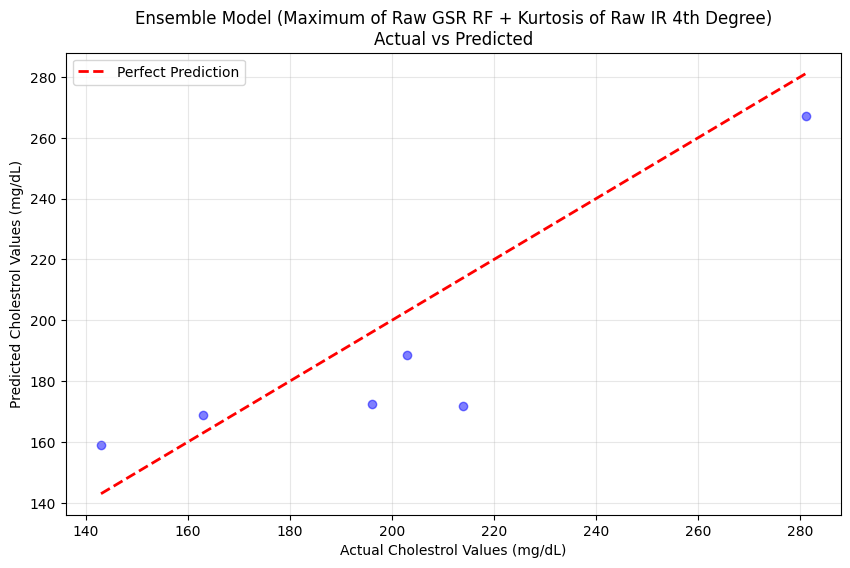

In [60]:

#

# --- Model 1: Random Forest on Peak to Peak of Raw RED IR ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x12_train, y2_train)
y_pred_rf_ensemble = rf.predict(x12_test)

# --- Model 2: Polynomial + Linear Regression on Peak to Peak of Raw RED IR ---
pl = PolynomialFeatures(degree=4)  
X_train_poly = pl.fit_transform(x5_train)
X_test_poly = pl.transform(x5_test)
lr = LinearRegression()
lr.fit(X_train_poly, y2_train)
y_pred_lr_ensemble = lr.predict(X_test_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y2_test.values.ravel()   

#--dhdhehehhehfhe MAPE
def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


mape_rf = calculate_mape(y_test_flat, y_pred_rf_ensemble)
mape_lr = calculate_mape(y_test_flat, y_pred_lr_ensemble)
mape_ensemble = calculate_mape(y_test_flat, y_pred_ensemble)
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")
print(f"Ensemble MAPE:          {mape_ensemble:.2f}%")
print(f"Ensemble Accuracy:      {100 - mape_ensemble:.2f}%")

##Showing

plt.figure(figsize=(10, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Cholestrol Values (mg/dL)')
plt.ylabel('Predicted Cholestrol Values (mg/dL)')
plt.title(f'Ensemble Model (Maximum of Raw GSR RF + Kurtosis of Raw IR 4th Degree)\nActual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
y2_test

,Chol.
0,143
0,203
0,214
0,196
0,163
0,281


In [62]:
y_pred_ensemble

array([158.95960662, 188.57510551, 171.89419712, 172.51986201,
       168.748941  , 267.18103076])

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


y_pred_rf shape: (20,)
y_pred_lr shape: (20,)
[199.40007417 179.04933952 156.61272717 167.59539719 172.22747164
 144.01708593 140.79638671 209.24663656 162.76498299 162.33204293
 184.24710822 174.33015465 174.62326608 178.84678197 184.25343456
 191.91773293 187.59991067 169.39952122 211.73193284 169.91801206]
Random Forest MAE: 19.1630
Poly+Linear MAE:    31.8390
Ensemble MAE:       24.7088
Ensemble R²:        0.4951
Ensemble MAPE:          13.58%
Ensemble Accuracy:      86.42%


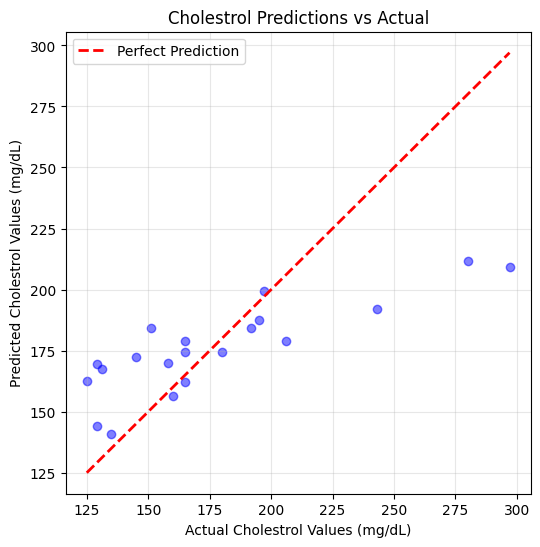

In [63]:

#

# --- Model 1: Random Forest on Peak to Peak of Raw RED IR ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x12_train, y2_train)
y_pred_rf_ensemble = rf.predict(x12_train)

# --- Model 2: Polynomial + Linear Regression on Peak to Peak of Raw RED IR ---
pl = PolynomialFeatures(degree=4)  
X_train_poly = pl.fit_transform(x5_train)
X_test_poly = pl.transform(x5_train)
lr = LinearRegression()
lr.fit(X_train_poly, y2_train)
y_pred_lr_ensemble = lr.predict(X_test_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y2_train.values.ravel()   

#--dhdhehehhehfhe MAPE
def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


mape_rf = calculate_mape(y_test_flat, y_pred_rf_ensemble)
mape_lr = calculate_mape(y_test_flat, y_pred_lr_ensemble)
mape_ensemble = calculate_mape(y_test_flat, y_pred_ensemble)
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")
print(f"Ensemble MAPE:          {mape_ensemble:.2f}%")
print(f"Ensemble Accuracy:      {100 - mape_ensemble:.2f}%")

##Showing

plt.figure(figsize=(6, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Cholestrol Values (mg/dL)')
plt.ylabel('Predicted Cholestrol Values (mg/dL)')
plt.title(f'Cholestrol Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Uric Acid

## Linear Regression

In [64]:
## Linear Regression
features = [
    ('Skewness of Raw RED IR', x1_train, x1_test),
    ('Kurtosis of Raw RED IR', x2_train, x2_test),
    ('Interquatile of Raw Infrared', x3_train, x3_test),
    ('Peak to Peak of Raw RED IR', x4_train, x4_test),
    ('[-] Kurtosis of Raw Infrared', x5_train, x5_test),
    ('[-] Average Peak of Raw Infrared', x6_train, x6_test),
    ('[-] Minimum of Raw GSR ', x7_train, x7_test),
    ('[-] 25% Quartile of Raw GSR ', x8_train, x8_test),
    ('[-] 50% Quartile of Raw GSR', x9_train, x9_test),
    ('[-] Mean of Raw GSR', x10_train, x10_test),
    ('[-] Root Mean Square of Raw GSR', x11_train, x11_test),
    ('[-] Maximum of Raw GSR', x12_train, x12_test),
    ('[-] 75% Quartile of Raw GSR', x13_train, x13_test)
    
]

results_LR = {}
more_accurate = []
not_accurate = []

for feature, X_train, X_test in features:
    lr = LinearRegression()
    lr.fit(X_train, y3_train)
    
    y3_pred_lr_train = lr.predict(X_train)
    mse_train = mean_squared_error(y3_train, y3_pred_lr_train)
    rmse_train = np.sqrt(mean_squared_error(y3_train, y3_pred_lr_train))
    r2_train = r2_score(y3_train, y3_pred_lr_train)
    mae_train = mean_absolute_error(y3_train, y3_pred_lr_train)
    
    y2_pred_lr = lr.predict(X_test)
    mse = mean_squared_error(y3_test, y2_pred_lr)
    rmse = np.sqrt(mean_squared_error(y3_test, y2_pred_lr))
    r2 = r2_score(y3_test, y2_pred_lr)
    mae = mean_absolute_error(y3_test, y2_pred_lr)
    y_test_1d = y3_test.values.ravel() if hasattr(y3_test, 'values') else y3_test.ravel()
    y_pred_1d = y2_pred_lr.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100
    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_LR[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y3_test, 
        'y_pred': y2_pred_lr,
        'coefficients': lr.coef_,
        'intercept': lr.intercept_,
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
            'mape': mape
    }

for feature, metrics in results_LR.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    
    if feature == 'BPM + O2':
        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)

        
    else:
        if metrics['MAE'] > arbitary_limit_test_uric and metrics['MAE_train'] > arbitary_limit_uric:
            plt.figure(figsize=(10, 6))
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics
            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Uric Acid Reading')
            plt.title(f'{feature} vs. Uric Acid Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")
            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients'][0]}")
            print(f"  Intercept: {metrics['intercept']}")
            print(f"=====================================\n")
            
            # current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # # Clean feature name by replacing problematic characters
            # def clean_filename(text):
            #     """Remove or replace characters that can break file paths"""
            #     # Replace common problematic characters
            #     invalid_chars = '<>:"/\\|?*'
            #     for char in invalid_chars:
            #         text = text.replace(char, '')
            #     # Replace spaces and brackets with underscores
            #     text = text.replace(' ', '_').replace('[', '').replace(']', '')
            #     # Remove any other non-alphanumeric characters (keep underscores and hyphens)
            #     text = ''.join(c for c in text if c.isalnum() or c in '_-')
            #     return text

            # # Inside your loop where you save the file:
            # fileName = f"LinearRegression-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # # Full path with folder
            # with open(f'GoodModels/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(metrics['model'], f)

## Random Forest

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

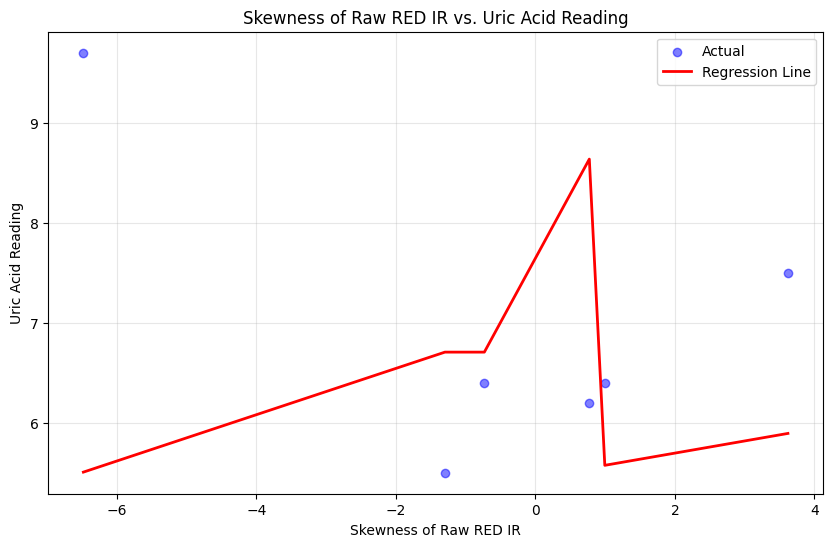

Feature: Skewness of Raw RED IR
Train data=

   MAE: 0.5994 mg/dL
   MSE: 0.5922 mg/dL
   RMSE: 0.7696 mg/dL
   R^2: 0.7629
Test data=

  Linear Regression MAE: 1.7625 mg/dL
  Linear Regression MSE: 4.7228 mg/dL
  Linear Regression RMSE: 2.1732 mg/dL
  Linear Regression R^2: -1.5448
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 76.07%



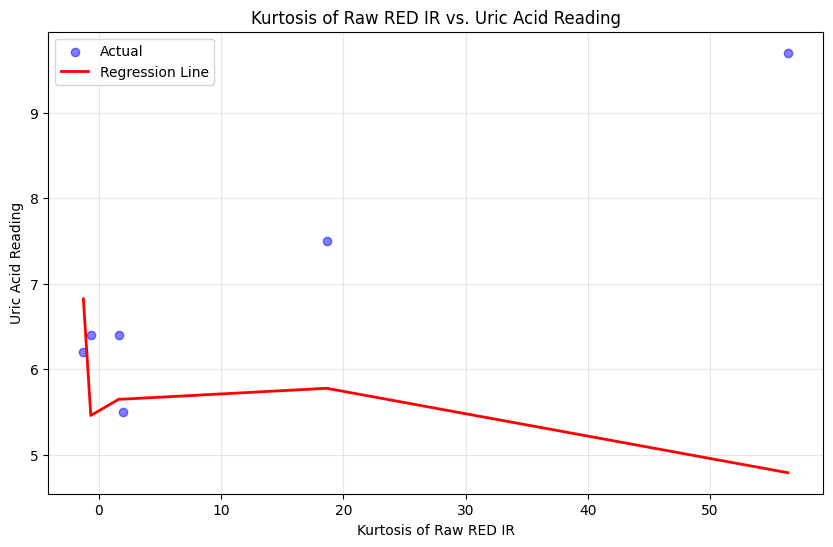

Feature: Kurtosis of Raw RED IR
Train data=

   MAE: 0.5994 mg/dL
   MSE: 0.5467 mg/dL
   RMSE: 0.7394 mg/dL
   R^2: 0.7811
Test data=

  Linear Regression MAE: 1.5160 mg/dL
  Linear Regression MSE: 4.8224 mg/dL
  Linear Regression RMSE: 2.1960 mg/dL
  Linear Regression R^2: -1.5985
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 81.20%



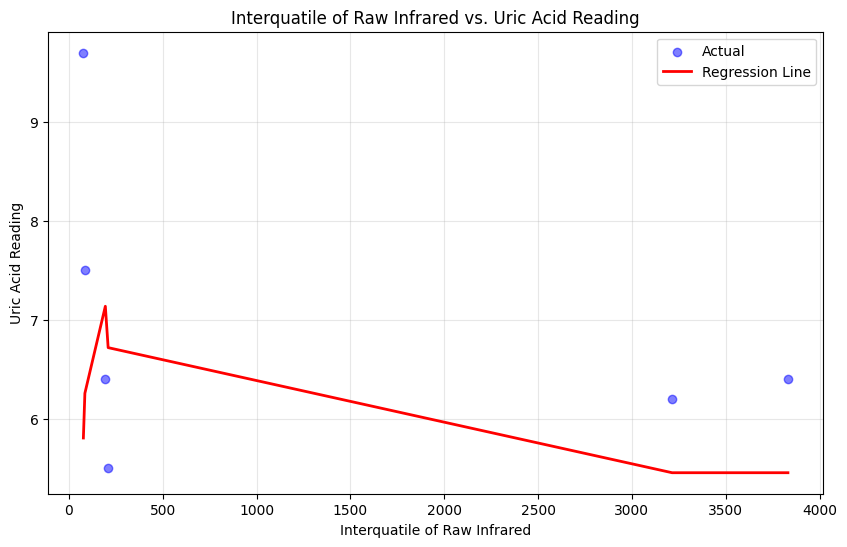

Feature: Interquatile of Raw Infrared
Train data=

   MAE: 0.6230 mg/dL
   MSE: 0.5692 mg/dL
   RMSE: 0.7545 mg/dL
   R^2: 0.7721
Test data=

  Linear Regression MAE: 1.4633 mg/dL
  Linear Regression MSE: 3.3622 mg/dL
  Linear Regression RMSE: 1.8336 mg/dL
  Linear Regression R^2: -0.8117
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 80.48%



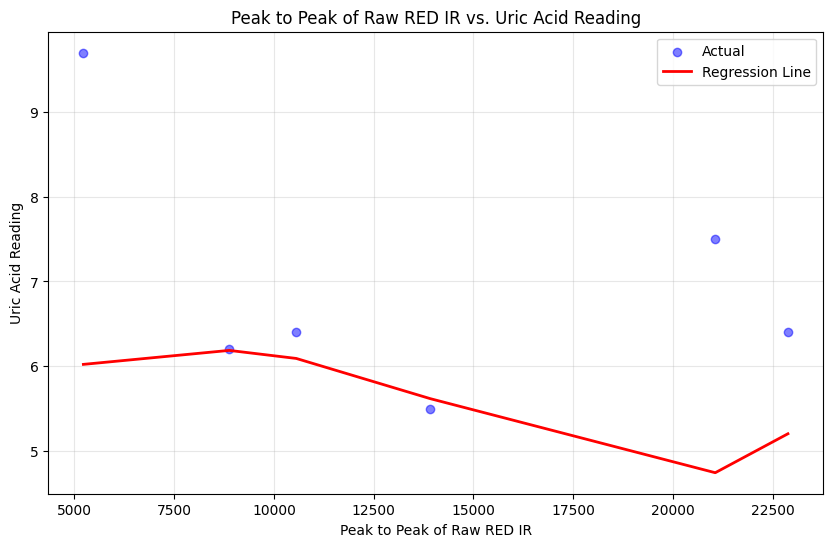

Feature: Peak to Peak of Raw RED IR
Train data=

   MAE: 0.6634 mg/dL
   MSE: 0.6321 mg/dL
   RMSE: 0.7950 mg/dL
   R^2: 0.7469
Test data=

  Linear Regression MAE: 1.3457 mg/dL
  Linear Regression MSE: 3.7810 mg/dL
  Linear Regression RMSE: 1.9445 mg/dL
  Linear Regression R^2: -1.0374
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 83.24%



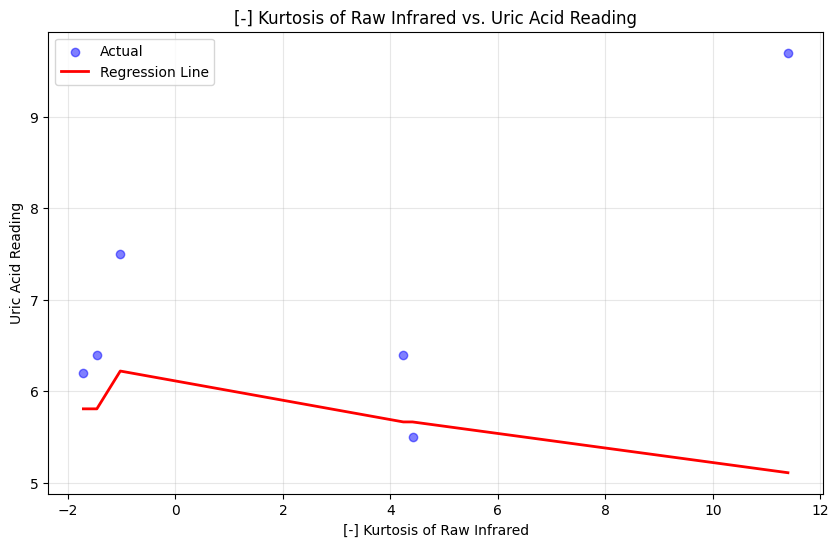

Feature: [-] Kurtosis of Raw Infrared
Train data=

   MAE: 0.5750 mg/dL
   MSE: 0.5477 mg/dL
   RMSE: 0.7400 mg/dL
   R^2: 0.7807
Test data=

  Linear Regression MAE: 1.2915 mg/dL
  Linear Regression MSE: 3.9601 mg/dL
  Linear Regression RMSE: 1.9900 mg/dL
  Linear Regression R^2: -1.1339
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 84.27%



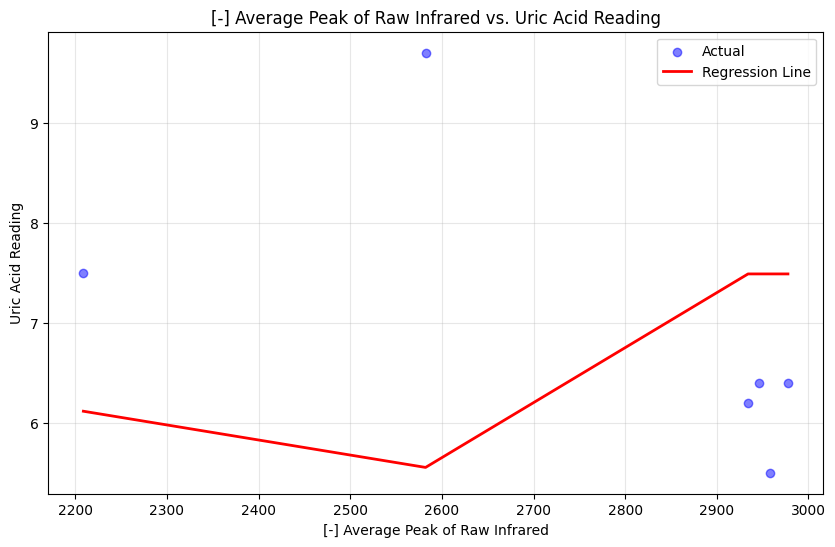

Feature: [-] Average Peak of Raw Infrared
Train data=

   MAE: 0.5500 mg/dL
   MSE: 0.5770 mg/dL
   RMSE: 0.7596 mg/dL
   R^2: 0.7690
Test data=

  Linear Regression MAE: 1.8307 mg/dL
  Linear Regression MSE: 4.5157 mg/dL
  Linear Regression RMSE: 2.1250 mg/dL
  Linear Regression R^2: -1.4333
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 74.64%



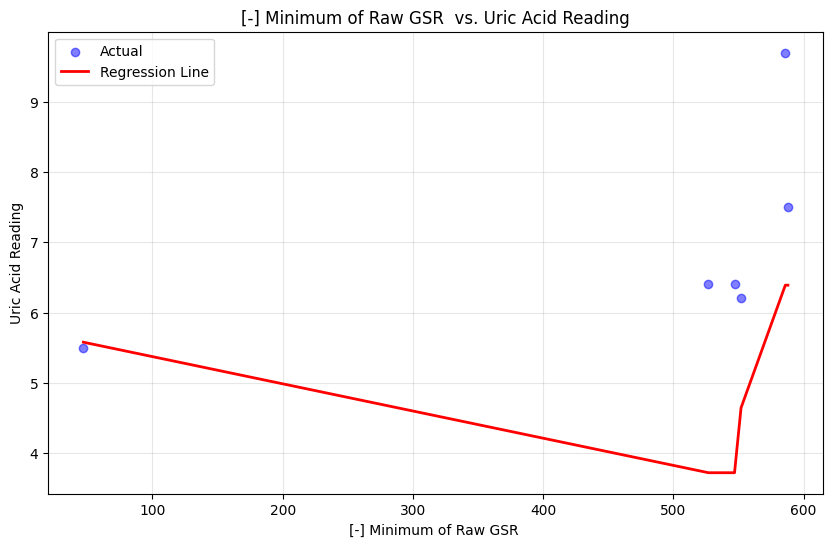

Feature: [-] Minimum of Raw GSR 
Train data=

   MAE: 0.5712 mg/dL
   MSE: 0.5151 mg/dL
   RMSE: 0.7177 mg/dL
   R^2: 0.7937
Test data=

  Linear Regression MAE: 1.9035 mg/dL
  Linear Regression MSE: 4.8361 mg/dL
  Linear Regression RMSE: 2.1991 mg/dL
  Linear Regression R^2: -1.6059
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 73.45%



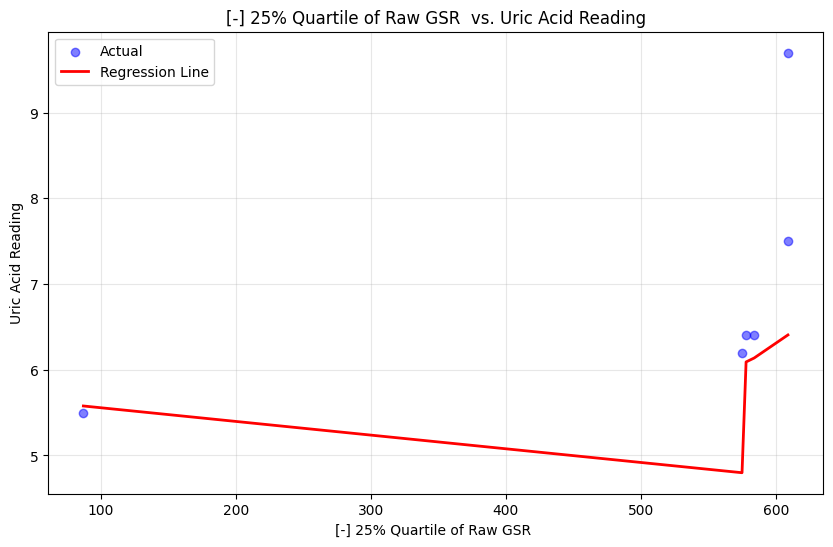

Feature: [-] 25% Quartile of Raw GSR 
Train data=

   MAE: 0.5875 mg/dL
   MSE: 0.5956 mg/dL
   RMSE: 0.7718 mg/dL
   R^2: 0.7615
Test data=

  Linear Regression MAE: 1.0732 mg/dL
  Linear Regression MSE: 2.3639 mg/dL
  Linear Regression RMSE: 1.5375 mg/dL
  Linear Regression R^2: -0.2738
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 86.42%



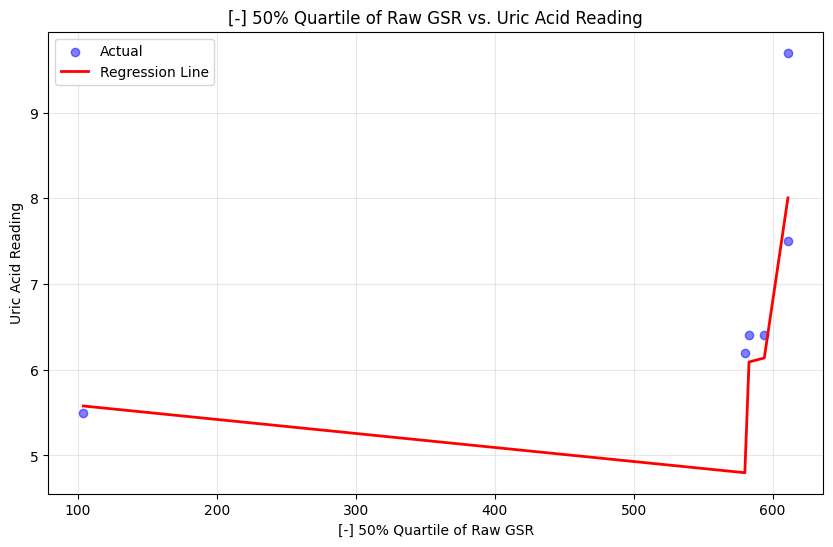

Feature: [-] 50% Quartile of Raw GSR
Train data=

   MAE: 0.5596 mg/dL
   MSE: 0.5525 mg/dL
   RMSE: 0.7433 mg/dL
   R^2: 0.7788
Test data=

  Linear Regression MAE: 0.7085 mg/dL
  Linear Regression MSE: 0.8774 mg/dL
  Linear Regression RMSE: 0.9367 mg/dL
  Linear Regression R^2: 0.5272
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 90.47%



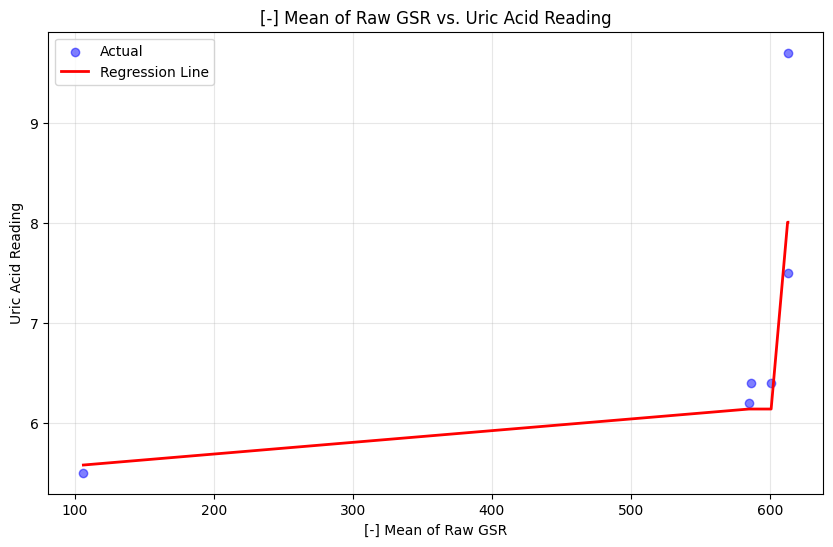

Feature: [-] Mean of Raw GSR
Train data=

   MAE: 0.5920 mg/dL
   MSE: 0.6039 mg/dL
   RMSE: 0.7771 mg/dL
   R^2: 0.7582
Test data=

  Linear Regression MAE: 0.4777 mg/dL
  Linear Regression MSE: 0.5460 mg/dL
  Linear Regression RMSE: 0.7390 mg/dL
  Linear Regression R^2: 0.7058
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 94.19%



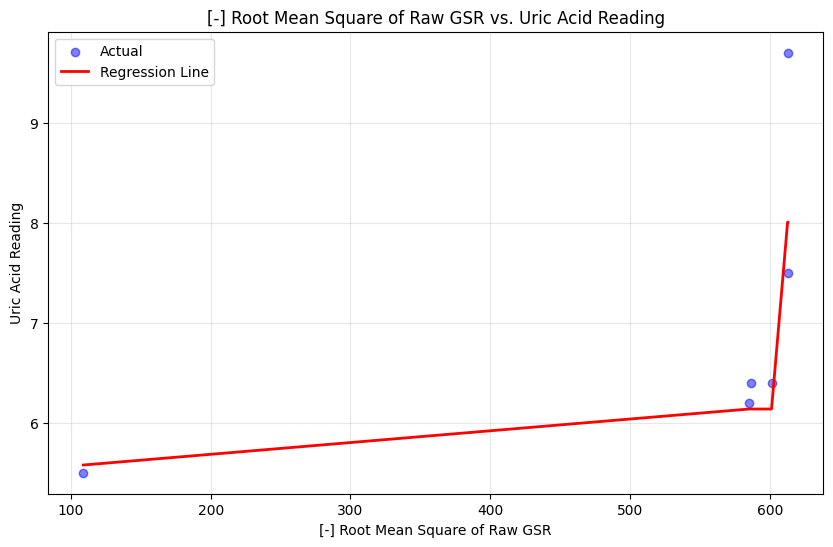

Feature: [-] Root Mean Square of Raw GSR
Train data=

   MAE: 0.5748 mg/dL
   MSE: 0.5872 mg/dL
   RMSE: 0.7663 mg/dL
   R^2: 0.7649
Test data=

  Linear Regression MAE: 0.4777 mg/dL
  Linear Regression MSE: 0.5460 mg/dL
  Linear Regression RMSE: 0.7390 mg/dL
  Linear Regression R^2: 0.7058
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 94.19%



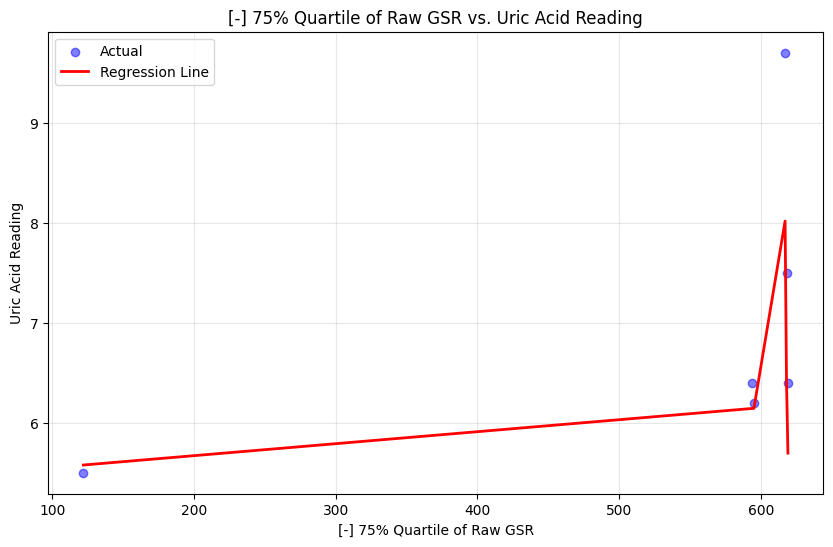

Feature: [-] 75% Quartile of Raw GSR
Train data=

   MAE: 0.5695 mg/dL
   MSE: 0.5563 mg/dL
   RMSE: 0.7458 mg/dL
   R^2: 0.7773
Test data=

  Linear Regression MAE: 0.6433 mg/dL
  Linear Regression MSE: 0.7623 mg/dL
  Linear Regression RMSE: 0.8731 mg/dL
  Linear Regression R^2: 0.5892
  Coefficient: [-4.69375403e-05]
  Intercept: [6.16746491]
   Accuracy: 91.81%



In [65]:

results_RF = {}
more_accurate_RF = []
not_accurate_RF = []

for feature, X_train, X_test in features:
    RF = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
    RF.fit(X_train, y3_train)
    
    y_pred_rf_train = RF.predict(X_train)
    mse_train = mean_squared_error(y3_train, y_pred_rf_train)
    rmse_train = np.sqrt(mean_squared_error(y3_train, y_pred_rf_train))
    r2_train = r2_score(y3_train, y_pred_rf_train)
    mae_train = mean_absolute_error(y3_train, y_pred_rf_train)
    
    y_pred_RF = RF.predict(X_test)
    mse = mean_squared_error(y3_test, y_pred_RF)
    rmse = np.sqrt(mean_squared_error(y3_test, y_pred_RF))
    r2 = r2_score(y3_test, y_pred_RF)
    mae = mean_absolute_error(y3_test, y_pred_RF)
    y_test_1d = y3_test.values.ravel() if hasattr(y3_test, 'values') else y3_test.ravel()
    y_pred_1d = y_pred_RF.ravel()
    mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100
    
    if r2 > 0.75:
        more_accurate.append(feature)   
    else:
        not_accurate.append(feature)
    
    results_RF[feature] = {
        'MAE': mae, 
        'MSE': mse, 
        'RMSE': rmse, 
        'R2': r2,
        'X_test': X_test, 
        'y_test': y3_test, 
        'y_pred': y_pred_RF,
        'coefficients': lr.coef_,
        'intercept': lr.intercept_,
        'MAE_train': mae_train,
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
        'model': RF,
            'mape': mape
    }

for feature, metrics in results_RF.items():
    
    
    X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
    y_pred_array = metrics['y_pred']
    if feature == 'BPM + O2':

        plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
        plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                 [metrics['y_test'].min(), metrics['y_test'].max()], 
                 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'{feature}\nActual vs Predicted')
        plt.grid(True, alpha=0.3)
        plt.show()
        # plt.subplot(1, 2, 2)
        # residuals = metrics['y_test'] - metrics['y_pred']
        # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
        # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
        # plt.xlabel('Predicted Values')
        # plt.ylabel('Residuals')
        # plt.title('Residual Plot')
        # plt.grid(True, alpha=0.3)
        # plt.show()

        
    else:
    # Flatten if needed and get sort indices
        if (metrics['MAE'] < arbitary_limit_test_uric and metrics['MAE_train'] < arbitary_limit_uric) :
            plt.figure(figsize=(10, 6))

            X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
            sort_idx = np.argsort(X_test_flat)
            
            X_test_sorted = X_test_flat[sort_idx]
            y_pred_sorted = y_pred_array[sort_idx]
            
            plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
            plt.plot(X_test_sorted, y_pred_sorted, color='red', label='Regression Line', linewidth=2)
            plt.xlabel(feature)
            plt.ylabel('Uric Acid Reading')
            plt.title(f'{feature} vs. Uric Acid Reading')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
    
            print(f"Feature: {feature}")
            print(f"Train data=\n")
            print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
            print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
            print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
            print(f"   R^2: {metrics['R2_train']:.4f}")
            print(f"Test data=\n")
            print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
            print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
            print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
            print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
            print(f"  Coefficient: {metrics['coefficients'][0]}")
            print(f"  Intercept: {metrics['intercept']}")
            print(f"   Accuracy: {metrics['mape']:.2f}%")
            print(f"=====================================\n")
            
            current_date = datetime.now().strftime("%Y%m%d")  # Format: 20260414

            # Clean feature name by replacing problematic characters
            def clean_filename(text):
                """Remove or replace characters that can break file paths"""
                # Replace common problematic characters
                invalid_chars = '<>:"/\\|?*'
                for char in invalid_chars:
                    text = text.replace(char, '')
                # Replace spaces and brackets with underscores
                text = text.replace(' ', '_').replace('[', '').replace(']', '')
                # Remove any other non-alphanumeric characters (keep underscores and hyphens)
                text = ''.join(c for c in text if c.isalnum() or c in '_-')
                return text

            # Inside your loop where you save the file:
            fileName = f"UricAcid-RandomForest-{clean_filename(feature)}-{round(metrics['MAE'])}-{current_date}"

            # Full path with folder
            # with open(f'GoodModels/UricAcid/{fileName}.pkl', 'wb') as f:
            #     pickle.dump(metrics['model'],f)
                
            # cmodel = emlearn.convert(metrics['model'], method='inline')
            # cmodel.save(file=f'GoodModels/UricAcid/RF/{fileName}.h', name='rf_gsr')
            
            

## Polynomial

DEGREE  1
DEGREE  2
DEGREE  3
DEGREE  4


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


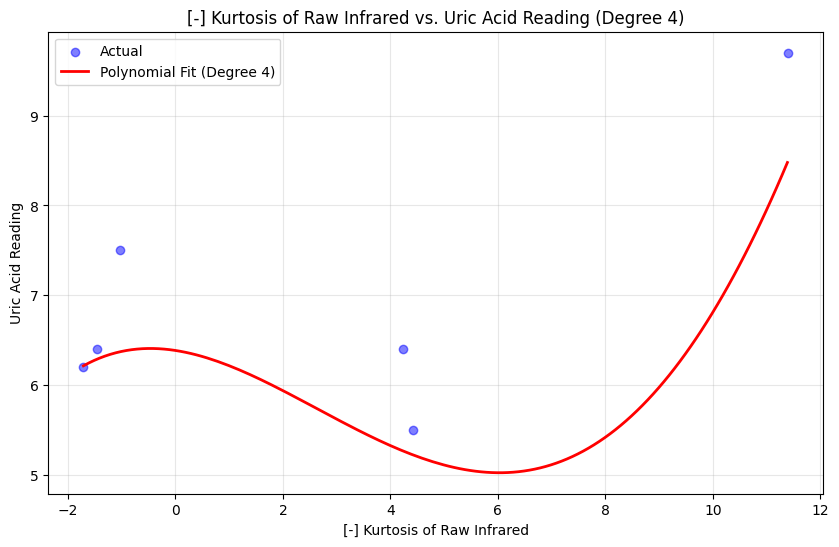

Feature: [-] Kurtosis of Raw Infrared
Train data=

   MAE: 1.1489 mg/dL
   MSE: 2.2979 mg/dL
   RMSE: 1.5159 mg/dL
   R^2: 0.0799
Test data=

  Linear Regression MAE: 0.6448 mg/dL
  Linear Regression MSE: 0.6836 mg/dL
  Linear Regression RMSE: 0.8268 mg/dL
  Linear Regression R^2: 0.6317
  Coefficient: [ 0.         -0.09240583 -0.08989593  0.01261649 -0.00022762]
  Intercept: [6.38647957]
   Accuracy: 91.31%

DEGREE  5
DEGREE  6
DEGREE  7
DEGREE  8
DEGREE  9


In [66]:
## POLUNOMIAL

results_PL = {}
emd_result_PL = {}
degree = 1

for feature, X_train, X_test in features:
    emd_result_PL[feature] = {}
    
for x in range(1, 10):
    print("DEGREE ", x)
    print("==" *50)
    for feature, X_train, X_test in features:
        # emd_result_PL[feature] = {}
        PL = PolynomialFeatures(degree=x)
        # PL.fit(X_train, y_train)
        X_train_poly = PL.fit_transform(X_train)
        X_test_poly = PL.transform(X_test)
        lr = LinearRegression()
        

        
        
        lr.fit(X_train_poly, y3_train)
        
        y_pred_pl_train = lr.predict(X_train_poly)
        mse_train = mean_squared_error(y3_train, y_pred_pl_train)
        rmse_train = np.sqrt(mean_squared_error(y3_train, y_pred_pl_train))
        r2_train = r2_score(y3_train, y_pred_pl_train)
        mae_train = mean_absolute_error(y3_train, y_pred_pl_train)
        
        
        y_pred_PL = lr.predict(X_test_poly)
        mse = mean_squared_error(y3_test, y_pred_PL)
        rmse = np.sqrt(mean_squared_error(y3_test, y_pred_PL))
        r2 = r2_score(y3_test, y_pred_PL)
        mae = mean_absolute_error(y3_test, y_pred_PL)
        y_test_1d = y3_test.values.ravel() if hasattr(y3_test, 'values') else y3_test.ravel()
        y_pred_1d = y_pred_PL.ravel()
        mape = 100 - np.mean(np.abs((y_test_1d - y_pred_1d) / y_test_1d)) * 100
        

        # if r2 > 0.75:
        #     more_accurate_NN.append(feature)   
        # else:
        #     not_accurate_NN.append(feature)
        
        results_PL[feature] = {
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
            'X_test': X_test, 
            'y_test': y3_test, 
            'y_pred': y_pred_PL,
            'coefficients': lr.coef_,
            'intercept': lr.intercept_,
            'MAE_train': mae_train,
            'MSE_train': mse_train,
            'RMSE_train': rmse_train,
            'R2_train': r2_train,
            'poly_features': PL,
            'model': lr,
            'degree': x ,
            'mape': mape
        }
        emd_result_PL[feature][x] = {
            'degree': x,
            'MAE': mae, 
            'MSE': mse, 
            'RMSE': rmse, 
            'R2': r2,
        }

    for feature, metrics in results_PL.items():
        if (metrics['MAE'] < arbitary_limit_test_uric and metrics['MAE_train'] < arbitary_limit_uric) and metrics['R2'] > arbitary_r_squared_limit:
        
            plt.figure(figsize=(10, 6))
            
            # Convert to numpy array and sort for plotting the regression line
            X_test_array = metrics['X_test'].values if hasattr(metrics['X_test'], 'values') else metrics['X_test']
            y_pred_array = metrics['y_pred']
            
            if feature == 'BPM + O2':
                # For multiple features: Show Actual vs Predicted plot
                # plt.subplot(1, 2, 1)
                plt.scatter(metrics['y_test'], metrics['y_pred'], alpha=0.5, color='blue')
                plt.plot([metrics['y_test'].min(), metrics['y_test'].max()], 
                        [metrics['y_test'].min(), metrics['y_test'].max()], 
                        'r--', lw=2)
                plt.xlabel('Actual Values')
                plt.ylabel('Predicted Values')
                plt.title(f'{feature}\nActual vs Predicted')
                plt.grid(True, alpha=0.3)
                plt.show()
                # Show residuals plot
                # plt.subplot(1, 2, 2)
                # residuals = metrics['y_test'] - metrics['y_pred']
                # plt.scatter(metrics['y_pred'], residuals, alpha=0.5, color='green', label='Actual')
                # plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Regression Line')
                # plt.xlabel('Predicted Values')
                # plt.ylabel('Residuals')
                # plt.title('Residual Plot')
                # plt.grid(True, alpha=0.3)
                
            else:
                
                PL = metrics['poly_features']
                model = metrics['model']
                degree_used = metrics['degree']
                
                # Create a smooth curve by generating points every 0.1
                X_test_flat = X_test_array.ravel() if hasattr(X_test_array, 'ravel') else X_test_array
                
                # Create a range of X values from min to max with 0.1 spacing
                X_smooth = np.arange(X_test_flat.min(), X_test_flat.max(), 0.1).reshape(-1, 1)
                
                # Transform the smooth X values using the same polynomial features
                X_smooth_poly = PL.transform(X_smooth)
                
                # Predict using the trained model
                y_smooth_pred = model.predict(X_smooth_poly)
                
                # Plot actual data points
                plt.scatter(metrics['X_test'], metrics['y_test'], alpha=0.5, label='Actual', color='blue')
                
                # Plot the smooth polynomial curve
                plt.plot(X_smooth, y_smooth_pred, color='red', label=f'Polynomial Fit (Degree {degree_used})', linewidth=2)
                
                plt.xlabel(feature)
                plt.ylabel('Uric Acid Reading')
                plt.title(f'{feature} vs. Uric Acid Reading (Degree {degree_used})')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()
  
            
                print(f"Feature: {feature}")
                print(f"Train data=\n")
                print(f"   MAE: {metrics['MAE_train']:.4f} mg/dL")
                print(f"   MSE: {metrics['MSE_train']:.4f} mg/dL")
                print(f"   RMSE: {metrics['RMSE_train']:.4f} mg/dL")
                print(f"   R^2: {metrics['R2_train']:.4f}")
                print(f"Test data=\n")
                print(f"  Linear Regression MAE: {metrics['MAE']:.4f} mg/dL")
                print(f"  Linear Regression MSE: {metrics['MSE']:.4f} mg/dL")
                print(f"  Linear Regression RMSE: {metrics['RMSE']:.4f} mg/dL")
                print(f"  Linear Regression R^2: {metrics['R2']:.4f}")
                print(f"  Coefficient: {metrics['coefficients'][0]}")
                print(f"  Intercept: {metrics['intercept']}")
                print(f"   Accuracy: {metrics['mape']:.2f}%")

                print(f"=====================================\n")
            

    

## Voting Model

c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


y_pred_rf shape: (6,)
y_pred_lr shape: (6,)
[5.70191041 7.18884346 6.17622672 5.40175271 6.21288008 8.24851787]
Random Forest MAE: 0.4777
Poly+Linear MAE:    0.6448
Ensemble MAE:       0.4616
Ensemble R²:        0.7543
Ensemble MAPE:          5.85%
Ensemble Accuracy:      94.15%


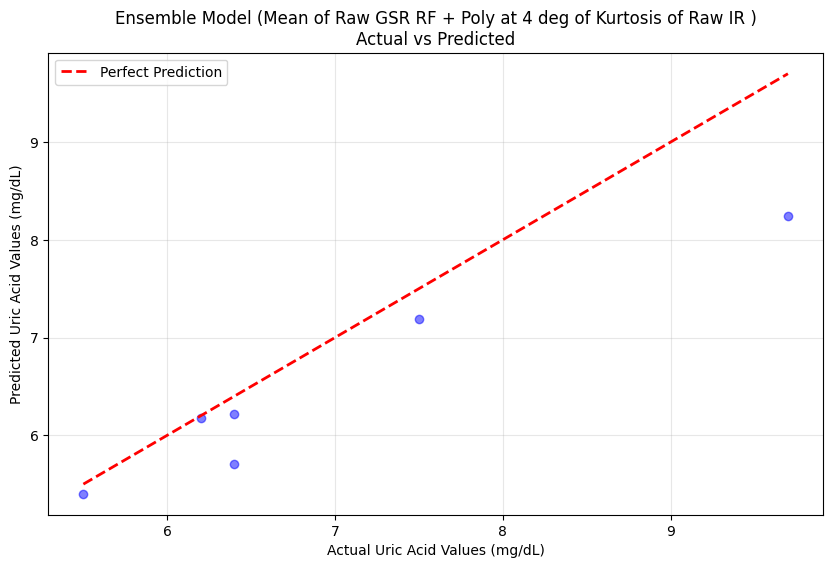

[6.4 7.5 6.2 5.5 6.4 9.7]
[5.70191041 7.18884346 6.17622672 5.40175271 6.21288008 8.24851787]


In [67]:

#

# --- Model 1: Random Forest on Interquatile of Raw Infrared ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x10_train, y3_train)
y_pred_rf_ensemble = rf.predict(x10_test)

# --- Model 2: Polynomial + Linear Regression on Kurtosis of Raw RED IR ---
pl = PolynomialFeatures(degree=4)   # 'x' should be defined (e.g., degree=2)
X_train_poly = pl.fit_transform(x5_train)
X_test_poly = pl.transform(x5_test)
lr = LinearRegression()
lr.fit(X_train_poly, y3_train)
y_pred_lr_ensemble = lr.predict(X_test_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y3_test.values.ravel()   
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)


def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


mape_rf = calculate_mape(y_test_flat, y_pred_rf_ensemble)
mape_lr = calculate_mape(y_test_flat, y_pred_lr_ensemble)
mape_ensemble = calculate_mape(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")
print(f"Ensemble MAPE:          {mape_ensemble:.2f}%")
print(f"Ensemble Accuracy:      {100 - mape_ensemble:.2f}%")
##Showing

plt.figure(figsize=(10, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Uric Acid Values (mg/dL)')
plt.ylabel('Predicted Uric Acid Values (mg/dL)')
plt.title(f'Ensemble Model (Mean of Raw GSR RF + Poly at 4 deg of Kurtosis of Raw IR )\nActual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(y_test_flat)
print(y_pred_ensemble)

In [68]:
y_pred_ensemble

array([5.70191041, 7.18884346, 6.17622672, 5.40175271, 6.21288008,
       8.24851787])

In [69]:
y3_test

,Uraic Acid
0,6.4
0,7.5
0,6.2
0,5.5
0,6.4
0,9.7


c:\Users\JASON ALEXANDER\miniconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


y_pred_rf shape: (20,)
y_pred_lr shape: (20,)
[5.35147984 6.22286667 5.91700129 5.90765414 6.27536568 5.41331123
 5.15147291 6.69035636 6.73010355 6.00768599 6.90938863 5.94370045
 7.09103725 6.64362275 7.18540536 5.98569438 5.06495756 6.159669
 6.22206562 6.31716134]
Random Forest MAE: 0.5920
Poly+Linear MAE:    1.1489
Ensemble MAE:       0.8532
Ensemble R²:        0.5023
Ensemble MAPE:          14.55%
Ensemble Accuracy:      85.45%


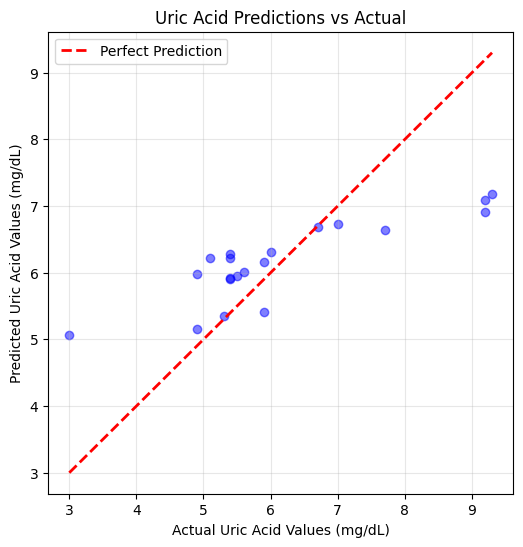

[5.3 5.4 5.4 5.4 5.4 5.9 4.9 6.7 7.  5.6 9.2 5.5 9.2 7.7 9.3 4.9 3.  5.9
 5.1 6. ]
[5.35147984 6.22286667 5.91700129 5.90765414 6.27536568 5.41331123
 5.15147291 6.69035636 6.73010355 6.00768599 6.90938863 5.94370045
 7.09103725 6.64362275 7.18540536 5.98569438 5.06495756 6.159669
 6.22206562 6.31716134]


In [70]:

#

# --- Model 1: Random Forest on Interquatile of Raw Infrared ---
rf = RandomForestRegressor(n_estimators=100, random_state=random_size_set)
rf.fit(x10_train, y3_train)
y_pred_rf_ensemble = rf.predict(x10_train)

# --- Model 2: Polynomial + Linear Regression on Kurtosis of Raw RED IR ---
pl = PolynomialFeatures(degree=4)   # 'x' should be defined (e.g., degree=2)
X_train_poly = pl.fit_transform(x5_train)
X_test_poly = pl.transform(x5_train)
lr = LinearRegression()
lr.fit(X_train_poly, y3_train)
y_pred_lr_ensemble = lr.predict(X_test_poly)

# --- Ensemble: simple average ---
y_pred_rf_ensemble = y_pred_rf_ensemble.ravel()      # ensures (3,)
y_pred_lr_ensemble = y_pred_lr_ensemble.ravel()      # converts (3,1) to (3,)
y_pred_ensemble = (y_pred_rf_ensemble + y_pred_lr_ensemble) / 2
y_test_flat = y3_train.values.ravel()   
# --- Evaluate ensemble ---
print("y_pred_rf shape:", y_pred_rf_ensemble.shape)
print("y_pred_lr shape:", y_pred_lr_ensemble.shape)
print(y_pred_ensemble)

# --- Evaluate ---
mae_ensemble = mean_absolute_error(y_test_flat, y_pred_ensemble)
r2_ensemble = r2_score(y_test_flat, y_pred_ensemble)


def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)"""
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


mape_rf = calculate_mape(y_test_flat, y_pred_rf_ensemble)
mape_lr = calculate_mape(y_test_flat, y_pred_lr_ensemble)
mape_ensemble = calculate_mape(y_test_flat, y_pred_ensemble)

print(f"Random Forest MAE: {mean_absolute_error(y_test_flat, y_pred_rf_ensemble):.4f}")
print(f"Poly+Linear MAE:    {mean_absolute_error(y_test_flat, y_pred_lr_ensemble):.4f}")
print(f"Ensemble MAE:       {mae_ensemble:.4f}")
print(f"Ensemble R²:        {r2_ensemble:.4f}")
print(f"Ensemble MAPE:          {mape_ensemble:.2f}%")
print(f"Ensemble Accuracy:      {100 - mape_ensemble:.2f}%")
##Showing

plt.figure(figsize=(6, 6))
plt.scatter(y_test_flat, y_pred_ensemble, alpha=0.5, color='blue')
plt.plot([y_test_flat.min(), y_test_flat.max()], 
         [y_test_flat.min(), y_test_flat.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Uric Acid Values (mg/dL)')
plt.ylabel('Predicted Uric Acid Values (mg/dL)')
plt.title(f'Uric Acid Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(y_test_flat)
print(y_pred_ensemble)